# Notebook 10: Activation Statistics - Monitoring Your Neural Network

---

## What This Notebook Covers

This notebook teaches you how to **monitor what's happening inside your neural network** during training. Understanding activation statistics is crucial for:

1. **Debugging training issues** - Why isn't my model learning?
2. **Detecting dead neurons** - ReLUs that never activate
3. **Identifying vanishing/exploding gradients** - Activations too small or too large
4. **Choosing better initialization** - Starting with healthy activations

We will learn:

1. **PyTorch Hooks** - How to peek inside any layer
2. **Hook Classes** - Clean, reusable hook management
3. **Activation Statistics** - Mean, std, histograms
4. **Dead ReLU Detection** - Finding neurons that stopped learning
5. **Visualization** - Color-coded histograms over time

---

## Why Monitor Activations?

Consider a deep neural network with many layers:

```
Input -> Layer1 -> Layer2 -> Layer3 -> ... -> LayerN -> Output
           ↓         ↓         ↓                ↓
        act_1     act_2     act_3    ...    act_N
```

**Problems that can occur:**

| Problem | What Happens | Symptoms |
|---------|-------------|----------|
| **Vanishing activations** | Values get smaller each layer | Mean → 0, Std → 0 |
| **Exploding activations** | Values get larger each layer | Mean/Std → infinity |
| **Dead ReLUs** | Neurons always output 0 | Many zeros in histogram |
| **Saturated activations** | All values at min/max | Histogram bunched at edges |

**Healthy activations** should have:
- Stable mean and standard deviation across layers
- Values spread across a reasonable range
- Few dead neurons

---

## 🎮 Interactive: see activations vanish, stay healthy, or explode

Before any code, build the intuition. A signal passes through many layers. Depending on how the weights are scaled, the **spread (std)** of the activations can shrink toward zero (*vanishing*), stay near one (*healthy*), or grow without bound (*exploding*). Pick a regime, drag the init-scale slider, and press **Animate flow** to watch the signal move layer by layer.

> Everything later in this notebook — hooks, histograms, `color_dim` — exists to *measure* exactly this behavior on a real network.

In [ ]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> shown FULL WIDTH that
# auto-fits its content height. No inline HTML -- the visualizations are read
# from GitHub, so the cells stay short.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(108,92,231,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&(e.data.type==="viz-height"||e.data.type==="ae-frame-height"||e.data.type==="ce-frame-height")&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/why_monitor_activations.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. Vanishing / healthy / exploding activations across layers.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/why_monitor_activations.html", height="560px")

# Part 1: Setup and Imports

---

In [ ]:
# =====================================================
# IMPORTS
# =====================================================

from __future__ import annotations
import random, math, torch, numpy as np, matplotlib.pyplot as plt
from functools import partial
from contextlib import contextmanager
from pathlib import Path
from operator import attrgetter, itemgetter
from collections.abc import Mapping

import torch.nn.functional as F
import matplotlib as mpl
from torch import tensor, nn, optim
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, default_collate
from datasets import load_dataset

# Display settings
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
mpl.rcParams['figure.constrained_layout.use'] = True

import logging
logging.disable(logging.WARNING)

In [ ]:
# =====================================================
# SET SEED FOR REPRODUCIBILITY
# =====================================================

def set_seed(seed, deterministic=False):
    """
    Set random seed for reproducibility.
    
    Arguments:
        seed         - The seed value to use
        deterministic - If True, use deterministic algorithms (slower but reproducible)
    
    Sets seeds for:
        - PyTorch (torch.manual_seed)
        - Python's random module
        - NumPy's random
    """
    torch.use_deterministic_algorithms(deterministic)
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [22]:
# =====================================================
# DEVICE SELECTION
# =====================================================

if torch.backends.mps.is_available():
    def_device = 'mps'
elif torch.cuda.is_available():
    def_device = 'cuda'
else:
    def_device = 'cpu'

print(f"Using device: {def_device}")

Using device: cpu


In [ ]:
# =====================================================
# HELPER FUNCTIONS
# =====================================================

def to_device(x, device=def_device):
    """Move tensor(s) to device."""
    if isinstance(x, torch.Tensor): return x.to(device)
    if isinstance(x, Mapping): return {k: to_device(v, device) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return type(x)(to_device(o, device) for o in x)
    return x

def to_cpu(x):
    """Move tensor to CPU and detach from graph."""
    if isinstance(x, Mapping): return {k: to_cpu(v) for k, v in x.items()}
    if isinstance(x, list): return [to_cpu(o) for o in x]
    if isinstance(x, tuple): return tuple(to_cpu(list(x)))
    if hasattr(x, 'detach'):
        res = x.detach().cpu()
        return res.float() if res.dtype == torch.float16 else res
    return x

def inplace(f):
    """Decorator that makes a function modify its argument in place."""
    def wrapper(b):
        f(b)
        return b
    return wrapper

def show_image(im, ax=None, figsize=(3,3), title=None, noframe=True, cmap=None, origin=None):
    """Display a single image."""
    if ax is None: fig, ax = plt.subplots(figsize=figsize)
    if hasattr(im, 'cpu'): im = im.detach().cpu()
    if hasattr(im, 'numpy'): im = im.numpy()
    ax.imshow(im, cmap=cmap, origin=origin)
    if title: ax.set_title(title)
    if noframe: ax.axis('off')
    return ax

def get_grid(n, nrows=None, ncols=None, figsize=None):
    """Create a grid of subplots."""
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = math.ceil(n / nrows)
    elif nrows is None: nrows = math.ceil(n / ncols)
    elif ncols is None: ncols = math.ceil(n / nrows)
    if figsize is None: figsize = (ncols*3, nrows*3)
    return plt.subplots(nrows, ncols, figsize=figsize)

---

# Part 2: Data and Model Setup

---

In [ ]:
# =====================================================
# LOAD FASHION MNIST
# =====================================================

x, y = 'image', 'label'
name = "zalando-datasets/fashion_mnist"
dsd = load_dataset(name)
bs = 1024

@inplace
def transformi(b):
    """Transform images to tensors (keep 2D for CNN)."""
    b[x] = [TF.to_tensor(o) for o in b[x]]

tds = dsd.with_transform(transformi)

In [ ]:
# =====================================================
# SIMPLIFIED DATALOADERS
# =====================================================

class DataLoaders:
    def __init__(self, train, valid):
        self.train = train
        self.valid = valid
    
    @classmethod
    def from_dd(cls, dd, bs, **kwargs):
        def collate(batch):
            images = torch.stack([b['image'] for b in batch])
            labels = tensor([b['label'] for b in batch])
            return images, labels
        train_dl = DataLoader(dd['train'], bs, shuffle=True, collate_fn=collate, **kwargs)
        valid_dl = DataLoader(dd['test'], bs, shuffle=False, collate_fn=collate, **kwargs)
        return cls(train_dl, valid_dl)

dls = DataLoaders.from_dd(tds, bs, num_workers=0)
dt = dls.train

---

## Baseline CNN Model

We'll use a simple CNN to study activations.

In [ ]:
# =====================================================
# CNN LAYER BUILDER
# =====================================================

def conv(ni, nf, ks=3, act=True):
    """
    Create a convolutional layer with optional ReLU.
    
    Arguments:
        ni  - Number of input channels
        nf  - Number of output channels (filters)
        ks  - Kernel size (default 3)
        act - Whether to add ReLU activation
    
    Returns:
        Conv2d layer (with ReLU if act=True)
    """
    res = nn.Conv2d(ni, nf, stride=2, kernel_size=ks, padding=ks//2)
    if act:
        res = nn.Sequential(res, nn.ReLU())
    return res

def cnn_layers():
    """
    Create the layers for our CNN.
    
    Architecture:
        Input:  1x28x28  (grayscale Fashion MNIST)
        Conv1:  8x14x14  (stride 2 halves spatial size)
        Conv2: 16x7x7
        Conv3: 32x4x4
        Conv4: 64x2x2
        Conv5: 10x1x1   (no ReLU - this is the output)
        Flatten: 10     (10 classes)
    """
    return [
        conv(1, 8, ks=5),        # 14x14
        conv(8, 16),             # 7x7
        conv(16, 32),            # 4x4
        conv(32, 64),            # 2x2
        conv(64, 10, act=False), # 1x1 (no ReLU for output!)
        nn.Flatten()
    ]

In [ ]:
# =====================================================
# SIMPLIFIED LEARNER AND CALLBACKS
# =====================================================

class Callback:
    order = 0

def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)

class CancelFitException(Exception): pass
class CancelBatchException(Exception): pass
class CancelEpochException(Exception): pass

class TrainCB(Callback):
    def __init__(self, n_inp=1): self.n_inp = n_inp
    def predict(self, learn): learn.preds = learn.model(*learn.batch[:self.n_inp])
    def get_loss(self, learn): learn.loss = learn.loss_func(learn.preds, *learn.batch[self.n_inp:])
    def backward(self, learn): learn.loss.backward()
    def step(self, learn): learn.opt.step()
    def zero_grad(self, learn): learn.opt.zero_grad()

class DeviceCB(Callback):
    def __init__(self, device=def_device): self.device = device
    def before_fit(self, learn): learn.model.to(self.device)
    def before_batch(self, learn): learn.batch = to_device(learn.batch, self.device)

class MetricsCB(Callback):
    def __init__(self, accuracy_metric):
        self.accuracy_metric = accuracy_metric
    def before_epoch(self, learn): self.accuracy_metric.reset()
    def after_batch(self, learn):
        self.accuracy_metric.update(to_cpu(learn.preds), to_cpu(learn.batch[1]))
    def after_epoch(self, learn):
        mode = 'train' if learn.model.training else 'valid'
        print(f"Epoch {learn.epoch} ({mode}): acc={self.accuracy_metric.compute():.4f}")

In [ ]:
# =====================================================
# SIMPLIFIED LEARNER
# =====================================================

class Learner:
    def __init__(self, model, dls, loss_func, lr, cbs):
        self.model = model
        self.dls = dls
        self.loss_func = loss_func
        self.lr = lr
        self.cbs = list(cbs) if cbs else []
    
    def one_batch(self):
        self.callback('predict')
        self.callback('get_loss')
        if self.model.training:
            self.callback('backward')
            self.callback('step')
            self.callback('zero_grad')
    
    def one_epoch(self, train):
        self.model.train(train)
        self.dl = self.dls.train if train else self.dls.valid
        try:
            self.callback('before_epoch')
            for self.iter, self.batch in enumerate(self.dl):
                try:
                    self.callback('before_batch')
                    self.one_batch()
                    self.callback('after_batch')
                except CancelBatchException: pass
            self.callback('after_epoch')
        except CancelEpochException: pass
    
    def fit(self, n_epochs):
        self.opt = optim.SGD(self.model.parameters(), self.lr)
        self.n_epochs = n_epochs
        try:
            self.callback('before_fit')
            for self.epoch in range(n_epochs):
                self.one_epoch(True)
                with torch.no_grad(): self.one_epoch(False)
            self.callback('after_fit')
        except CancelFitException: pass
    
    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)
    
    @property
    def training(self): return self.model.training

In [ ]:
# =====================================================
# TRAINING HELPER FUNCTION
# =====================================================

try:
    from torcheval.metrics import MulticlassAccuracy
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'torcheval'])
    from torcheval.metrics import MulticlassAccuracy

metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]

def fit(model, epochs=1, xtra_cbs=None):
    """
    Train a model with standard callbacks + optional extras.
    
    Arguments:
        model     - The model to train
        epochs    - Number of epochs
        xtra_cbs  - Additional callbacks (e.g., for activation stats)
    
    Returns:
        The Learner object
    """
    learn = Learner(model, dls, loss_func=F.cross_entropy, lr=0.6,  cbs=cbs+fc.L(xtra_cbs))
    learn.fit(epochs)
    return learn

accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


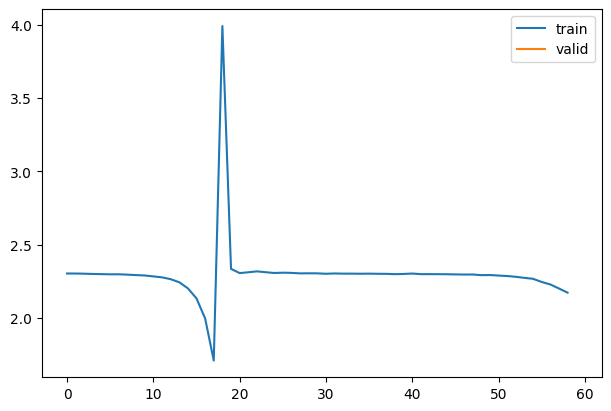

In [33]:
# =====================================================
# BASELINE TRAINING
# =====================================================

set_seed(1)
model = nn.Sequential(*cnn_layers())
learn = fit(model)

The model trains, but we have no idea what's happening inside! Let's fix that.

---

---

# Part 3: Manual Activation Tracking

---

The most straightforward way to track activations is to modify the model to record them.

**Approach:** Create a custom Sequential that stores activation statistics after each layer.

In [ ]:
# =====================================================
# SEQUENTIAL MODEL WITH ACTIVATION TRACKING
# =====================================================

class SequentialModel(nn.Module):
    """
    A Sequential model that tracks activation statistics.
    
    Stores mean and standard deviation of activations
    after each layer, for every batch.
    
    Attributes:
        layers    - The layers of the model
        act_means - List of lists: act_means[layer_idx] = [mean1, mean2, ...]
        act_stds  - Same for standard deviations
    """
    
    def __init__(self, *layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        # Initialize storage for each layer
        self.act_means = [[] for _ in layers]
        self.act_stds = [[] for _ in layers]
        
    def __call__(self, x):
        """
        Forward pass with activation tracking.
        
        After each layer, we:
        1. Move activations to CPU (for memory efficiency)
        2. Compute and store mean and std
        """
        for i, layer in enumerate(self.layers):
            x = layer(x)
            # Track statistics (move to CPU to save GPU memory)
            self.act_means[i].append(to_cpu(x).mean().item())
            self.act_stds[i].append(to_cpu(x).std().item())
        return x
    
    def __iter__(self):
        """Allow iterating over layers."""
        return iter(self.layers)

accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


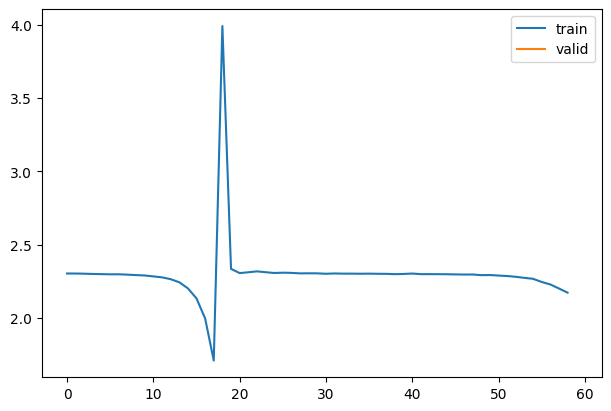

In [35]:
# =====================================================
# TRAIN WITH ACTIVATION TRACKING
# =====================================================

set_seed(1)
model = SequentialModel(*cnn_layers())
learn = fit(model)

# How `__call__` Works in `SequentialModel` — From Python's Callable Protocol to the Training Loop

---

## The Question

In the `SequentialModel` class from Part 3 of the notebook, a `__call__` method is defined:

```python
class SequentialModel(nn.Module):
    def __init__(self, *layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.act_means = [[] for _ in layers]
        self.act_stds = [[] for _ in layers]
        
    def __call__(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            self.act_means[i].append(to_cpu(x).mean().item())
            self.act_stds[i].append(to_cpu(x).std().item())
        return x
```

But nowhere in the code does anyone write `model.__call__(x)`. So what calls it, and how?

---

## Python's Callable Protocol

This is a fundamental Python language feature, not something specific to PyTorch or this notebook.

In Python, **any object can be "called" like a function if its class defines a `__call__` method.** This is part of Python's data model — the set of special "dunder" methods that Python translates operator syntax into behind the scenes.

The rule is simple: when Python encounters `obj(args)`, it looks up `__call__` on the object's class and executes `type(obj).__call__(obj, args)`.

This is the same mechanism behind many other dunder methods:

| Syntax you write | What Python actually executes |
|---|---|
| `obj(x)` | `obj.__call__(x)` |
| `obj[i]` | `obj.__getitem__(i)` |
| `obj + other` | `obj.__add__(other)` |
| `len(obj)` | `obj.__len__()` |
| `for x in obj` | `obj.__iter__()` |
| `str(obj)` | `obj.__str__()` |

You've already seen the iteration one in this notebook — `for h in hc` calls `hc.__iter__()`. The callable protocol with `__call__` works exactly the same way.

### Concrete Example

```python
class Adder:
    def __init__(self, n):
        self.n = n
    
    def __call__(self, x):
        return x + self.n

add_five = Adder(5)
add_five(10)  # Python translates this to add_five.__call__(10) → returns 15
```

`add_five` is not a function — it's an instance of `Adder`. But because `Adder` defines `__call__`, you can use it with parentheses as if it were a function. Python doesn't care *what* an object is; it only cares whether the object's class has a `__call__` method.

---

## Where `__call__` Gets Triggered in the Training Loop

The `__call__` method is never called by name anywhere in the code. Instead, it's triggered inside `TrainCB`:

```python
class TrainCB(Callback):
    def predict(self, learn): learn.preds = learn.model(*learn.batch[:self.n_inp])
```

Here, `learn.model` is the `SequentialModel` instance. When Python sees `learn.model(*learn.batch[:self.n_inp])`, it executes `learn.model.__call__(*learn.batch[:self.n_inp])`.

### The Full Call Chain

```
learn.fit(n_epochs)
  └─ learn.one_epoch(train=True)
       └─ learn.one_batch()
            └─ learn.callback('predict')
                 └─ TrainCB.predict(learn)
                      └─ learn.preds = learn.model(*learn.batch[:self.n_inp])
                                        │
                                        ▼
                           SequentialModel.__call__(x)
                           │  for each layer:
                           │    x = layer(x)
                           │    record mean, std
                           │  return x
```

`learn.batch[:self.n_inp]` with `n_inp=1` extracts the images tensor from the batch tuple `(images, labels)`, and the `*` unpacks it so the images tensor is passed as the single argument `x`.

---

## Tracing Through the Actual Code

Let's trace exactly what happens when this code runs:

```python
set_seed(1)
model = SequentialModel(*cnn_layers())
learn = fit(model)
```

### Step 1: `fit(model)` Creates a Learner

```python
def fit(model, epochs=1, xtra_cbs=None):
    learn = Learner(model, dls, loss_func=F.cross_entropy, lr=0.6, cbs=cbs+fc.L(xtra_cbs))
    learn.fit(epochs)
    return learn
```

At this point `learn.model` is the `SequentialModel(*cnn_layers())` object you passed in.

### Step 2: `learn.fit(epochs)` Starts Training

```python
def fit(self, n_epochs):
    self.opt = optim.SGD(self.model.parameters(), self.lr)
    ...
    for self.epoch in range(n_epochs):
        self.one_epoch(True)     # ← training
        ...
```

### Step 3: `one_epoch` Loops Over Batches

```python
def one_epoch(self, train):
    self.model.train(train)
    self.dl = self.dls.train if train else self.dls.valid
    ...
    for self.iter, self.batch in enumerate(self.dl):
        ...
        self.one_batch()
        ...
```

Now `self.batch` is a tuple like `(images_tensor, labels_tensor)` from the dataloader.

### Step 4: `one_batch` Calls `predict`

```python
def one_batch(self):
    self.callback('predict')   # ← this is the key line
    self.callback('get_loss')
    ...
```

`self.callback('predict')` calls `run_cbs`, which finds `TrainCB.predict` and executes it.

### Step 5: `TrainCB.predict` — Where `__call__` Gets Triggered

```python
class TrainCB(Callback):
    def __init__(self, n_inp=1): self.n_inp = n_inp
    def predict(self, learn): learn.preds = learn.model(*learn.batch[:self.n_inp])
```

Let's unpack `learn.model(*learn.batch[:self.n_inp])` piece by piece:

```
learn.batch = (images_tensor, labels_tensor)

self.n_inp = 1

learn.batch[:1] = (images_tensor,)          # slice gives a tuple with one element

*learn.batch[:1]  → images_tensor            # * unpacks the tuple

learn.model(images_tensor)                   # this is the final call
```

Now Python sees `learn.model(images_tensor)`. It asks: **is `learn.model` callable?**

`learn.model` is a `SequentialModel` object. `SequentialModel` defines `__call__`. So Python invokes it:

```
learn.model(images_tensor)
    ↓
SequentialModel.__call__(self=learn.model, x=images_tensor)
    ↓
    for i, layer in enumerate(self.layers):
        x = layer(x)
        self.act_means[i].append(to_cpu(x).mean().item())
        self.act_stds[i].append(to_cpu(x).std().item())
    return x
```

That's it. Python sees parentheses after an object, looks for `__call__` on its class, and executes it. No registration, no special setup — defining `__call__` on a class is sufficient.

---

## An Important Nuance: `__call__` vs `forward`

Because `SequentialModel` inherits from `nn.Module`, there's a subtlety worth noting. Normally in PyTorch, you define `forward()` (not `__call__`), because `nn.Module.__call__` does important bookkeeping — it handles hooks, sets training mode flags, and then calls `self.forward()`. By overriding `__call__` directly, this class **bypasses that machinery**. That's fine for this pedagogical example (and actually makes the code simpler to understand), but it means PyTorch's built-in hooks won't fire on this model — which is ironic given that the very next section of the notebook introduces hooks.

This is intentional. Part 3 is meant to be the "naive approach" that motivates the cleaner hook-based solution in Parts 4–9.

For comparison, if the code had used `nn.Sequential` instead:

```python
model = nn.Sequential(*cnn_layers())   # standard PyTorch model
learn = fit(model)
```

Then `learn.model(images_tensor)` would follow the standard PyTorch path:

```
learn.model(images_tensor)
    ↓
nn.Module.__call__(self=learn.model, images_tensor)
    ↓  (inside __call__, after hooks/bookkeeping)
    self.forward(images_tensor)
    ↓
    nn.Sequential.forward(images_tensor)
    ↓  (loops through each layer, passing output to next)
    layer0(x) → layer1(x) → layer2(x) → ... → output
```

The `SequentialModel` from Part 3 skips the `nn.Module.__call__` → `forward()` indirection entirely. Both paths end up running data through the layers, but only the standard path supports PyTorch's hook system.

/tmp/ipykernel_3906/1575042365.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


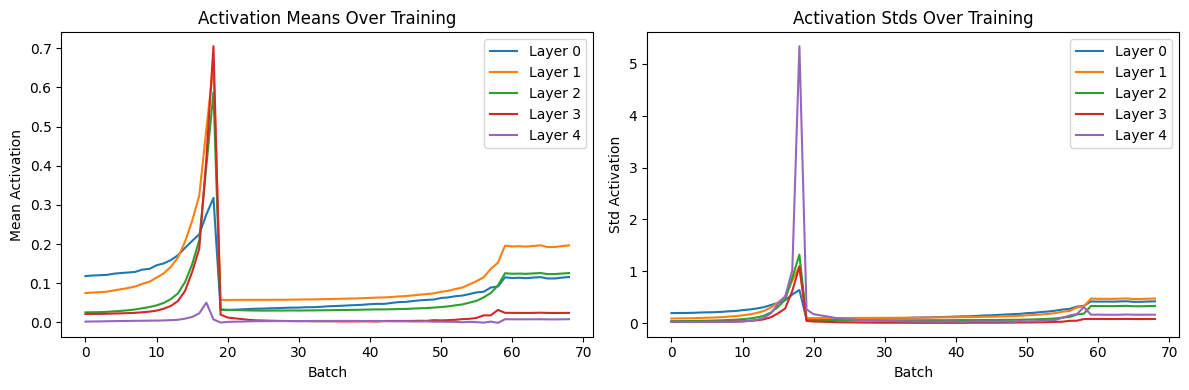

In [36]:
# =====================================================
# PLOT ACTIVATION MEANS
# =====================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for i, means in enumerate(model.act_means[:5]):  # First 5 layers (conv layers)
    plt.plot(means, label=f'Layer {i}')
plt.xlabel('Batch')
plt.ylabel('Mean Activation')
plt.title('Activation Means Over Training')
plt.legend()

# =====================================================
# PLOT ACTIVATION STDS
# =====================================================

plt.subplot(1, 2, 2)
for i, stds in enumerate(model.act_stds[:5]):
    plt.plot(stds, label=f'Layer {i}')
plt.xlabel('Batch')
plt.ylabel('Std Activation')
plt.title('Activation Stds Over Training')
plt.legend()

plt.tight_layout()

**What to look for:**

1. **Means near 0** - Activations centered around 0 (good for ReLU input)
2. **Stable stds** - Standard deviations that don't explode or vanish
3. **Consistency across layers** - Similar statistics in all layers

**Problems with this approach:**
- We had to modify the model
- Not reusable for other models
- Couples activation tracking with model logic

---

---

# Part 4: PyTorch Hooks

---

## What Are Hooks?

**Hooks** are PyTorch's built-in mechanism to "peek inside" any layer without modifying it.

A hook is a function that gets called automatically when:
- **Forward hook**: A layer computes its output
- **Backward hook**: Gradients flow through a layer

**Key benefit:** No need to modify the model!

---

## Forward Hook Signature

A forward hook function receives three arguments:

```python
def hook_fn(module, input, output):
    # module: The layer this hook is attached to
    # input:  The input to the layer (tuple)
    # output: The output of the layer
    pass
```

---

## 🎮 Interactive: how a forward hook fires

A hook is a function PyTorch calls **for you**, right after a layer produces its output. Step through the five stages (or press **Play**) to see exactly when your `append_stats(module, input, output)` runs — the matching line of code lights up on the right. Notice you never call the hook yourself, and the model is never modified.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/forward_hook_flow.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. How a forward hook fires (the 5 stages).
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/forward_hook_flow.html", height="560px")

In [ ]:
# =====================================================
# USING PYTORCH HOOKS
# =====================================================

set_seed(1)
model = nn.Sequential(*cnn_layers())

# Storage for activation statistics
# One list per layer to store means/stds for each batch
act_means = [[] for _ in model]
act_stds = [[] for _ in model]

In [ ]:
# =====================================================
# DEFINE THE HOOK FUNCTION
# =====================================================

def append_stats(i, mod, inp, outp):
    """
    Hook function that records activation statistics.
    
    Arguments:
        i     - Layer index (we'll use partial to set this)
        mod   - The module (layer) this hook is attached to
        inp   - Input to the layer (tuple)
        outp  - Output of the layer (the activations!)
    
    This function appends the mean and std of the output
    to our global storage lists.
    """
    act_means[i].append(to_cpu(outp).mean().item())
    act_stds[i].append(to_cpu(outp).std().item())

In [40]:
# =====================================================
# REGISTER HOOKS ON ALL LAYERS
# =====================================================

# For each layer, register a forward hook
# partial(append_stats, i) creates a version of append_stats
# with the layer index 'i' already filled in

for i, m in enumerate(model):
    m.register_forward_hook(partial(append_stats, i)) # here, m is a layer of the model

print(f"Registered hooks on {len(list(model))} layers")

Registered hooks on 6 layers


accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


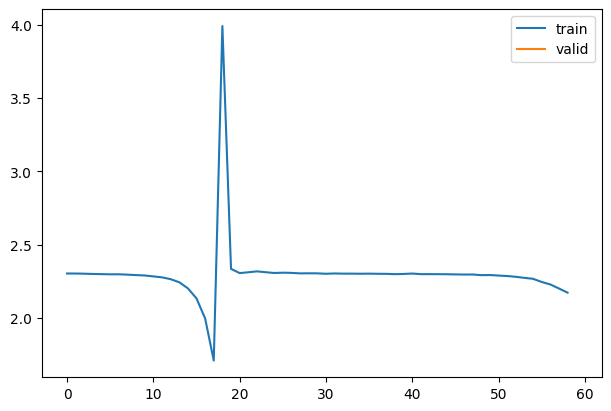

In [41]:
# Train the model - hooks will automatically record stats!
fit(model)

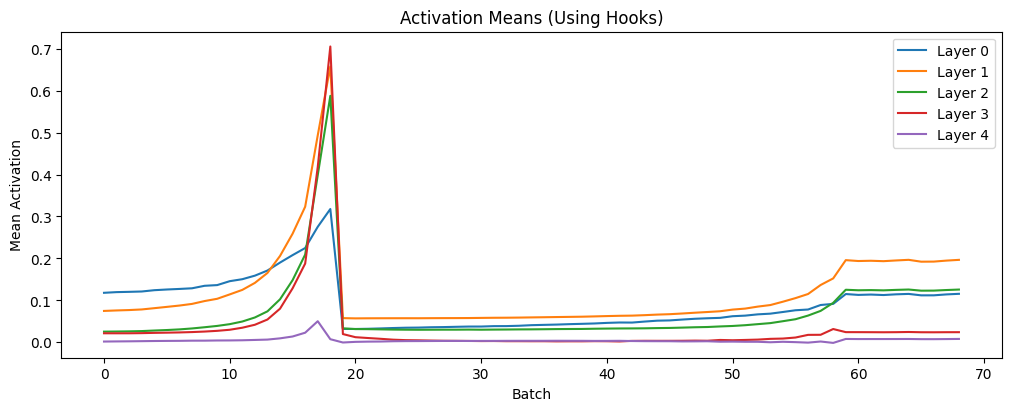

In [42]:
# Plot the recorded statistics
plt.figure(figsize=(10, 4))
for i, means in enumerate(act_means[:5]):
    plt.plot(means, label=f'Layer {i}')
plt.xlabel('Batch')
plt.ylabel('Mean Activation')
plt.title('Activation Means (Using Hooks)')
plt.legend()

# How PyTorch Forward Hooks and `partial` Work Together

## The Setup

In the activations notebook, we have this code:

```python
# Storage for activation statistics
act_means = [[] for _ in model]
act_stds = [[] for _ in model]

def append_stats(i, mod, inp, outp):
    act_means[i].append(to_cpu(outp).mean().item())
    act_stds[i].append(to_cpu(outp).std().item())

for i, m in enumerate(model):
    m.register_forward_hook(partial(append_stats, i))

fit(model)
```

The question is: how does all of this actually work? Let's trace through it step by step.

---

## Step 1: What `partial` Does

`partial` is from Python's `functools`. It creates a **new function** from an existing one by pre-filling some arguments. Our `append_stats` has four parameters:

```python
def append_stats(i, mod, inp, outp):
```

When you write `partial(append_stats, i)` — say `i=0` — it creates a brand new function that behaves exactly like:

```python
def new_function(mod, inp, outp):
    return append_stats(0, mod, inp, outp)
```

The first argument `i` is now permanently baked in as `0`. The new function only needs the remaining three arguments: `mod`, `inp`, `outp`.

So inside the loop:

```python
for i, m in enumerate(model):
    m.register_forward_hook(partial(append_stats, i))
```

For a 5-layer model, this creates five different functions, each with its own layer index frozen in: `partial(append_stats, 0)`, `partial(append_stats, 1)`, `partial(append_stats, 2)`, etc.

---

## Step 2: What `register_forward_hook` Does

When you call `m.register_forward_hook(some_function)`, PyTorch doesn't run `some_function` immediately. It simply stores it internally on that layer, like putting a sticky note on it saying "call this function every time data flows through me."

The contract is: PyTorch will call your hook function with exactly three arguments — `(module, input, output)` — every time that layer's forward pass completes. This is a PyTorch-defined signature that you must match.

So after registration, layer 0 has `partial(append_stats, 0)` stored on it, layer 1 has `partial(append_stats, 1)`, and so on. Nothing has executed yet.

---

## Step 3: What Happens When `fit(model)` Runs

The `fit` function creates a `Learner` and calls `learn.fit(epochs)`, which loops over batches. For each batch, the `TrainCB.predict` method runs:

```python
self.learn.preds = self.learn.model(self.learn.batch[0])
```

This calls `model(x)` — the forward pass. Since `model` is `nn.Sequential`, data flows through each layer in sequence. When data passes through, say, layer 0 (the first conv block), PyTorch internally does something like this:

```python
# Inside PyTorch's internals (simplified):
output = layer_0.forward(input)        # compute the layer's output normally

# Then PyTorch checks: does this layer have any hooks?
for hook_fn in layer_0._forward_hooks:
    hook_fn(layer_0, input, output)     # call each registered hook
```

That `hook_fn` is `partial(append_stats, 0)`, which needs three arguments — and PyTorch supplies exactly those three: `(module, input, output)`. So the call becomes:

```python
partial(append_stats, 0)(layer_0, input, output)
```

which is equivalent to:

```python
append_stats(0, layer_0, input, output)
```

Now all four parameters have values: `i=0` (from `partial`), `mod=layer_0`, `inp=input`, `outp=output` (all three from PyTorch). Inside `append_stats`, it computes `outp.mean()` and `outp.std()` and appends them to `act_means[0]` and `act_stds[0]`.

Then data flows to layer 1, and the same thing happens — PyTorch calls `partial(append_stats, 1)(layer_1, input, output)`, which stores stats in `act_means[1]` and `act_stds[1]`. And so on for every layer, on every batch.

---

## Step 4: The Names Don't Matter — The Position Does

You might wonder: how does PyTorch know which argument is the input and which is the output? Does it look at the names `inp` and `outp`?

**No.** You can name them anything you want. These would all work identically:

```python
def append_stats(i, mod, inp, outp):        # original
def append_stats(i, layer, x_in, x_out):    # also fine
def append_stats(i, m, a, b):               # also fine
def append_stats(i, banana, apple, orange):  # even this works
```

Python matches arguments **by position**, not by name. The first argument gets the first value, the second gets the second, and so on.

Somewhere deep inside PyTorch's source code for `nn.Module`, the forward hook call looks roughly like this (simplified):

```python
# Inside PyTorch's nn.Module.__call__ (simplified)
class Module:
    def __call__(self, *args):
        output = self.forward(*args)          # run the actual layer computation

        for hook_fn in self._forward_hooks:
            hook_fn(self, args, output)       # position 1, position 2, position 3

        return output
```

PyTorch doesn't know or care what your parameter names are. It just passes three values **in a fixed order**: the module first, the input second, the output third. Always. Every time. It's a contract PyTorch defines.

When PyTorch calls your hook on layer 0:

```python
hook_fn(self,     args,    output)
#       ↓         ↓        ↓         ← PyTorch passes 3 values in order
```

And `hook_fn` is `partial(append_stats, 0)`, which already has `i=0` baked in, so it's waiting for three more arguments. Python matches them left to right:

```
append_stats(  i,     mod,     inp,     outp   )
               ↑       ↑        ↑        ↑
              0      self     args    output
           (partial) (1st)    (2nd)    (3rd)
```

If you had named them `banana, apple, orange`:

```
append_stats(  i,     banana,  apple,   orange )
               ↑       ↑        ↑        ↑
              0      self     args    output
           (partial) (1st)    (2nd)    (3rd)
```

`orange` would hold the output tensor. The name is just a label for you, the programmer — Python and PyTorch only care about **which position** each value lands in.

This is exactly how all Python functions work. When you write `def add(a, b): return a + b` and call `add(3, 5)`, Python doesn't look for a variable named `a` with value 3. It just assigns the first argument to the first parameter and the second to the second.

---

## The Complete Timeline

```
REGISTRATION PHASE (before any training):
  for i=0: layer_0 stores partial(append_stats, 0)    ← no execution
  for i=1: layer_1 stores partial(append_stats, 1)    ← no execution
  ...

TRAINING PHASE — fit(model) → each batch:
  model(x) triggers the forward pass:
    layer_0(x)  → PyTorch auto-calls partial(append_stats, 0)(layer_0, inp, outp)
                   → append_stats(0, layer_0, inp, outp)
                   → act_means[0].append(outp.mean())

    layer_1(...)→ PyTorch auto-calls partial(append_stats, 1)(layer_1, inp, outp)
                   → append_stats(1, layer_1, inp, outp)
                   → act_means[1].append(outp.mean())
    ...
```

So `partial` solves a specific problem: PyTorch's hook signature is fixed at `(module, input, output)` — you can't pass extra arguments like the layer index. By using `partial`, you "smuggle in" the layer index ahead of time, creating a custom function per layer that still matches PyTorch's expected three-argument signature.

**Same result, but we didn't modify the model!**

**Problem:** The hooks are still attached to the model. If we delete the model, the hooks keep it alive in memory. We need to clean up!

---

---

# Part 5: The Hook Class

---

Let's create a class to manage hooks properly:
- Store the hook function's state
- Automatically remove the hook when done
- Prevent memory leaks

In [ ]:
# =====================================================
# HOOK CLASS
# =====================================================

class Hook:
    """
    A class to manage a single PyTorch hook.
    
    Key features:
    - Registers the hook on creation
    - Stores state that the hook function can access (via self)
    - Removes the hook when deleted (prevents memory leaks!)
    
    Arguments:
        m - The module (layer) to attach the hook to
        f - The hook function. It will be called with:
            f(hook, module, input, output)
            Note: 'hook' (self) is passed as first argument
    
    The hook function can store data on 'hook' (e.g., hook.stats = ...)
    """
    
    def __init__(self, m, f):
        # Register the hook, passing self as first argument to f
        # partial(f, self) creates a function that calls f(self, ...)
        self.hook = m.register_forward_hook(partial(f, self))
    
    def remove(self):
        """Remove the hook from the module."""
        self.hook.remove()
        """
        self.hook.remove() — This calls PyTorch's built-in remove method. When you call 
        m.register_forward_hook(...), PyTorch returns a RemovableHandle object. That handle 
        has a .remove() method that tells PyTorch "stop calling this hook function, detach it from 
        the layer." That's what self.hook stores — that PyTorch handle.
        """
    
    def __del__(self):
        """
        Called when the Hook object is deleted.
        
        This ensures the hook is removed from the module,
        preventing memory leaks.
        """
        self.remove()

In [ ]:
# =====================================================
# UPDATED HOOK FUNCTION
# =====================================================

def append_stats(hook, mod, inp, outp):
    """
    Hook function that stores stats ON THE HOOK OBJECT.
    
    Arguments:
        hook - The Hook object (we store stats here!)
        mod  - The module
        inp  - Input to the module
        outp - Output of the module
    
    Instead of using global lists, we store stats on the hook:
        hook.stats = (means_list, stds_list)
    """
    # Initialize stats storage if not present
    if not hasattr(hook, 'stats'):
        hook.stats = ([], [])  # (means, stds)
    
    # Compute and store statistics
    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean().item())
    hook.stats[1].append(acts.std().item())

In [45]:
# =====================================================
# USING THE HOOK CLASS
# =====================================================

set_seed(1)
model = nn.Sequential(*cnn_layers())

# Create hooks for the first 5 layers (the conv layers)
# model[:5] gets the first 5 elements
# .children() iterates over direct child modules
hooks = [Hook(layer, append_stats) for layer in list(model.children())[:5]]

print(f"Created {len(hooks)} hooks")

Created 5 hooks


accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


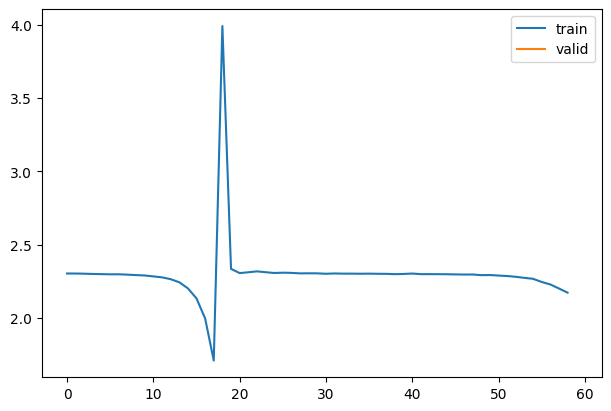

In [46]:
# Train
learn = fit(model)

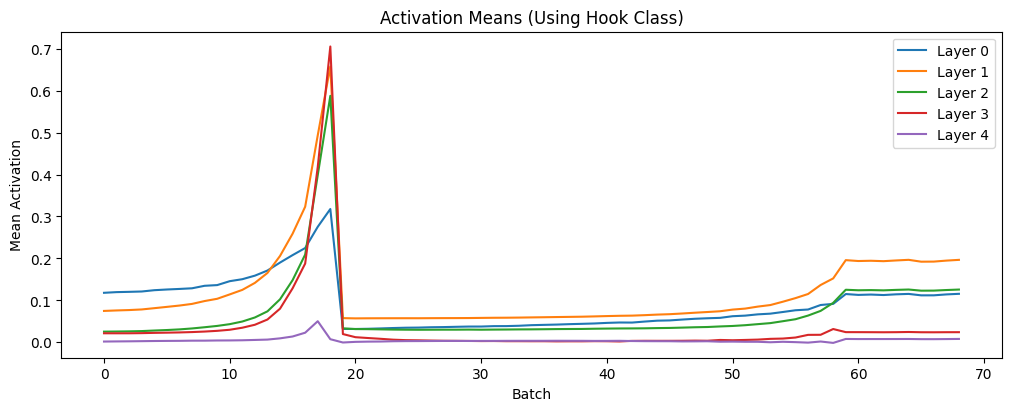

In [47]:
# =====================================================
# PLOT AND CLEANUP
# =====================================================

plt.figure(figsize=(10, 4))
for i, h in enumerate(hooks):
    plt.plot(h.stats[0], label=f'Layer {i}')  # Plot means
    h.remove()  # Clean up the hook!

plt.xlabel('Batch')
plt.ylabel('Mean Activation')
plt.title('Activation Means (Using Hook Class)')
plt.legend()

**Key improvement:** Each hook stores its own data, and we clean up properly.

---

---

# Part 6: The Hooks Class (Context Manager)

---

Managing multiple hooks is tedious. Let's create a `Hooks` class that:
- Creates hooks for multiple layers at once
- Automatically cleans up using Python's `with` statement

## Context Managers Refresher

A **context manager** is an object used with the `with` statement:

```python
with SomeContextManager() as obj:
    # obj.__enter__() is called
    do_something(obj)
# obj.__exit__() is called (even if exception occurred)
```

This is perfect for automatic cleanup!

In [48]:
# =====================================================
# CONTEXT MANAGER EXAMPLE
# =====================================================

class DummyCtxMgr:
    """
    A simple example of a context manager.
    
    __enter__ is called when entering the 'with' block
    __exit__ is called when leaving (even on exception)
    """
    
    def __enter__(self, *args):
        print("Entering context (setup)")
        return self  # This becomes the 'as' variable
    
    def __exit__(self, *args):
        print("Exiting context (cleanup)")
    
    def hello(self):
        print("Hello from inside the context!")

# Test it
with DummyCtxMgr() as dcm:
    dcm.hello()

Entering context (setup)
Hello from inside the context!
Exiting context (cleanup)


In [ ]:
# =====================================================
# THE HOOKS CLASS
# =====================================================

class Hooks(list):
    """
    A list of hooks that can be used as a context manager.
    
    Features:
    - Inherits from list (can iterate, index, etc.)
    - Creates hooks for multiple modules at once
    - Automatic cleanup with 'with' statement
    - Proper cleanup when deleting individual items
    
    Usage:
        with Hooks(model, append_stats) as hooks:
            train(model)
            # use hooks[i].stats
        # hooks are automatically removed here
    """
    
    def __init__(self, ms, f):
        """
        Create hooks for multiple modules.
        
        Arguments:
            ms - Iterable of modules to hook
            f  - Hook function
        """
        super().__init__([Hook(m, f) for m in ms])
    
    def __enter__(self, *args):
        """Context manager entry - just return self."""
        return self
    
    def __exit__(self, *args):
        """Context manager exit - remove all hooks."""
        self.remove()
    
    def __del__(self):
        """Destructor - remove all hooks."""
        self.remove()
    
    def __delitem__(self, i):
        """When deleting an item, remove its hook first."""
        self[i].remove()
        super().__delitem__(i)
    
    def remove(self):
        """Remove all hooks."""
        for h in self:
            h.remove()

accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


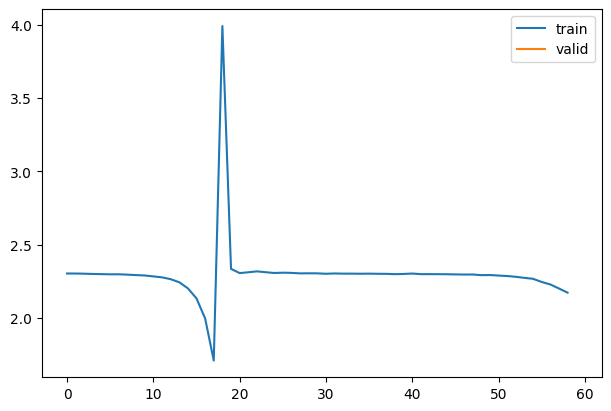

Hooks have been automatically removed


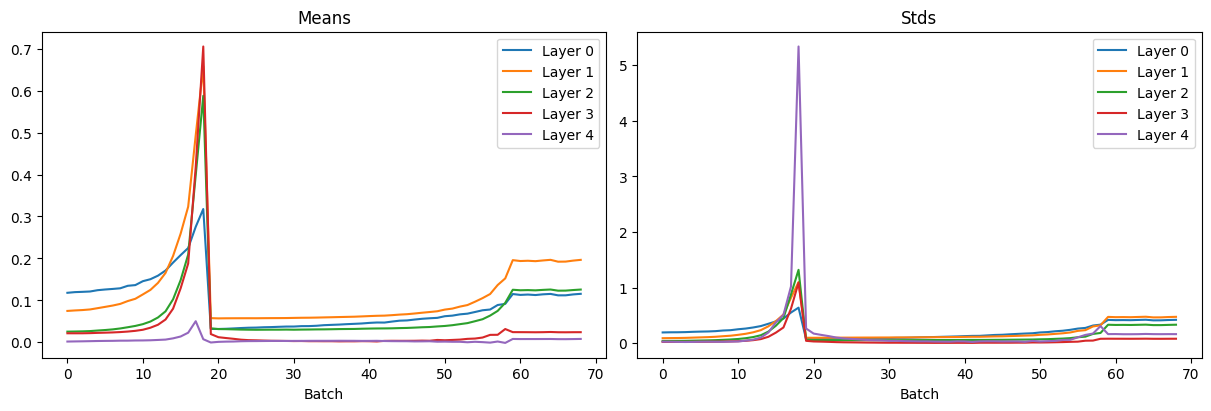

In [50]:
# =====================================================
# USING HOOKS WITH CONTEXT MANAGER
# =====================================================

set_seed(1)
model = nn.Sequential(*cnn_layers())

# Use 'with' for automatic cleanup
with Hooks(model, append_stats) as hooks:
    fit(model)
    
    # Plot while hooks are still available
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    for i, h in enumerate(hooks[:5]):  # First 5 layers
        axs[0].plot(h.stats[0], label=f'Layer {i}')
        axs[1].plot(h.stats[1], label=f'Layer {i}')
    
    axs[0].set_title('Means')
    axs[0].set_xlabel('Batch')
    axs[0].legend()
    
    axs[1].set_title('Stds')
    axs[1].set_xlabel('Batch')
    axs[1].legend()

# Hooks are automatically cleaned up here!
print("Hooks have been automatically removed")

# The `Hooks` Class — Motivation, What's New, and How It Works

---

## Motivation: Why Do We Need a `Hooks` Class?

After Part 5 introduced the `Hook` class, we had a clean way to attach a hook to a **single** layer, store stats on the hook object, and remove it when done. But in practice, we never want to hook just one layer — we want to monitor **all** the convolutional layers (or all layers) in a model simultaneously. Here's what that looked like with the `Hook` class alone:

```python
set_seed(1)
model = nn.Sequential(*cnn_layers())

# Manually create hooks one by one
hooks = [Hook(layer, append_stats) for layer in list(model.children())[:5]]

learn = fit(model)

# Plot and MANUALLY clean up each hook
plt.figure(figsize=(10, 4))
for i, h in enumerate(hooks):
    plt.plot(h.stats[0], label=f'Layer {i}')
    h.remove()  # Must remember to do this for EACH hook!
```

This works, but it has three problems:

1. **Manual creation** — you write a list comprehension yourself to create individual `Hook` objects every time
2. **Manual cleanup** — you must remember to call `h.remove()` on every single hook when you're done
3. **No safety net** — if your code crashes between creating hooks and removing them, the hooks leak in memory. The PyTorch hooks remain attached to the modules, keeping those modules (and their tensors) alive even after you think you've discarded them

Problem 3 is particularly insidious because it's silent — your code won't throw an error, it will just consume more and more GPU/CPU memory.

The `Hooks` class solves all three problems by wrapping the batch creation into a single constructor call and leveraging Python's **context manager protocol** to guarantee cleanup.

---

## What Stays the Same: Each Hook Is Still Tied to One Layer

Before looking at what's new, it's important to understand what the `Hooks` class does **not** change — the per-layer hook association.

When the `Hook` class was used directly, each `Hook` was already attached to a specific layer:

```python
hooks = [Hook(l, append_stats) for l in model[:5].children()]
```

Python iterates over the first 5 children of the model. For a model built from `cnn_layers()`, those children are:

```
l = Sequential(Conv2d(1→8), ReLU)     →  Hook(l, append_stats)  →  hooks[0]
l = Sequential(Conv2d(8→16), ReLU)    →  Hook(l, append_stats)  →  hooks[1]
l = Sequential(Conv2d(16→32), ReLU)   →  Hook(l, append_stats)  →  hooks[2]
l = Sequential(Conv2d(32→64), ReLU)   →  Hook(l, append_stats)  →  hooks[3]
l = Conv2d(64→10)                     →  Hook(l, append_stats)  →  hooks[4]
```

Inside each `Hook.__init__`, the line `self.hook = m.register_forward_hook(partial(f, self))` registers the hook **on that specific module `m`**. So `hooks[0]` is permanently attached to the first Sequential block, `hooks[1]` to the second, and so on. Each `Hook` object stores stats only for the layer it was registered on — when that layer's forward pass fires, PyTorch calls the hook function with that layer's output, and `append_stats` records it on that particular `Hook` object's `.stats`.

The `Hooks` class does **exactly the same thing** internally. Its `__init__`:

```python
super().__init__([Hook(m, f) for m in ms])
```

is doing the same `Hook(m, f)` call for each module. Same `Hook` objects, same `register_forward_hook` calls, same per-layer association. The hook mechanism is identical — what changes is only how we **manage** those hooks.

---

## What's Different With the `Hooks` Class

### Before: `Hook` Class Directly

```python
hooks = [Hook(layer, append_stats) for layer in list(model.children())[:5]]
fit(model)
for h in hooks:
    h.remove()  # Must remember this!
```

### After: `Hooks` Class

```python
with Hooks(model, append_stats) as hooks:
    fit(model)
    for i, h in enumerate(hooks[:5]):
        axs[0].plot(h.stats[0], label=f'Layer {i}')
# Hooks are automatically cleaned up here!
```

Two things changed: **batch creation** and **automatic cleanup via context manager**.

---

## Difference 1: Batch Creation

Instead of manually writing a list comprehension, `Hooks.__init__` does it for you:

```python
class Hooks(list):
    def __init__(self, ms, f):
        super().__init__([Hook(m, f) for m in ms])
```

When you write `Hooks(model, append_stats)`, Python calls this `__init__`, which:

1. Iterates over `model` (which yields the 6 child modules of `nn.Sequential`)
2. Creates a `Hook(m, append_stats)` for each one
3. Passes the resulting list to `list.__init__` via `super().__init__(...)`

So `Hooks` *is* a `list` — it inherits from `list`. After construction, it's literally a list containing 6 `Hook` objects. That's why `hooks[:5]`, `hooks[i]`, `len(hooks)`, and `for h in hooks` all work — they're standard list operations inherited from `list`.

---

## Difference 2: Automatic Cleanup via Context Manager

This is the main reason `Hooks` exists. The `with` statement uses Python's **context manager protocol**, which relies on two dunder methods:

```python
def __enter__(self, *args):
    return self

def __exit__(self, *args):
    self.remove()
```

Here's what happens when Python executes the `with` block:

```
with Hooks(model, append_stats) as hooks:
│
├─ Step 1: Python creates the Hooks object
│    Hooks(model, append_stats)  →  a list of 6 Hook objects
│
├─ Step 2: Python calls __enter__()
│    returns self  →  this becomes the variable 'hooks'
│
├─ Step 3: The indented block runs
│    fit(model)           ← hooks are active, recording stats
│    for i, h in ...      ← plotting from recorded stats
│
└─ Step 4: Python calls __exit__() — GUARANTEED, even if an exception occurs
     self.remove()
       └─ for h in self:
              h.remove()   ← removes each hook from its module
```

The critical guarantee is Step 4. Compare these two scenarios:

**Without context manager** — if `fit(model)` crashes:
```python
hooks = [Hook(layer, append_stats) for layer in model.children()]
fit(model)        # ← CRASH! Exception thrown
for h in hooks:
    h.remove()    # ← This line NEVER executes. Hooks leak.
```

**With context manager** — if `fit(model)` crashes:
```python
with Hooks(model, append_stats) as hooks:
    fit(model)    # ← CRASH! Exception thrown
                  # Python STILL calls __exit__(), which calls self.remove()
                  # All hooks are cleaned up safely
```

This is the same pattern as `with open('file.txt') as f:` — the file gets closed even if your code throws an error.

---

## The Additional Safety Methods

The `Hooks` class also defines two more cleanup methods for edge cases:

**`__del__` — fallback if someone forgets `with`:**

```python
def __del__(self):
    self.remove()
```

If someone writes `hooks = Hooks(model, append_stats)` without `with`, the hooks will still be cleaned up when the `hooks` variable gets garbage collected by Python.

**`__delitem__` — safe deletion of individual hooks:**

```python
def __delitem__(self, i):
    self[i].remove()
    super().__delitem__(i)
```

This handles `del hooks[2]`. Without this override, `del hooks[2]` would remove the `Hook` object from the list but leave the actual PyTorch hook still attached to the module — a subtle leak. The override ensures the PyTorch hook is removed from the module first, then the `Hook` object is removed from the list.

---

## Summary

| Concern | `Hook` class alone | `Hooks` class |
|---|---|---|
| Layer-to-hook association | `Hook(l, f)` registers on layer `l` | Identical — internally creates `Hook(m, f)` for each module |
| Creating multiple hooks | Manual list comprehension | `Hooks(model, f)` does it in one call |
| Cleanup on success | Must call `h.remove()` on each | `with` block calls `__exit__` → `remove()` automatically |
| Cleanup on crash | Hooks leak | `__exit__` is guaranteed by Python, even on exceptions |
| Cleanup if you forget | Hooks leak | `__del__` as a fallback safety net |
| Deleting one hook | Must remember to call `.remove()` first | `__delitem__` handles it |

The `Hooks` class doesn't change the hook mechanism at all — each hook is still attached to a specific layer via `register_forward_hook`, and each `Hook` object still stores stats only for its own layer. What `Hooks` adds is purely a **management wrapper**: convenience for creating multiple hooks in one call, and safety for guaranteeing they all get cleaned up.

---

# Part 7: HooksCallback

---

Now let's integrate hooks into our Learner callback system.

In [ ]:
#| export
class HooksCallback(Callback):
    def __init__(self, hookfunc, mod_filter=fc.noop, on_train=True, on_valid=False, mods=None):
        fc.store_attr()
        super().__init__()
    
    def before_fit(self, learn):
        if self.mods: mods=self.mods
        else: mods = fc.filter_ex(learn.model.modules(), self.mod_filter)
        self.hooks = Hooks(mods, partial(self._hookfunc, learn))

    def _hookfunc(self, learn, *args, **kwargs):
        if (self.on_train and learn.training) or (self.on_valid and not learn.training): self.hookfunc(*args, **kwargs)

    def after_fit(self, learn): self.hooks.remove()
    def __iter__(self): return iter(self.hooks)
    def __len__(self): return len(self.hooks)

In [ ]:
#| export

# `HooksCallback` — Every Line Explained

# This #| is a special comment used by nbdev (a tool for creating Python libraries
# from notebooks). It tells nbdev: "include this code in the exported library module."
# You can ignore this line — it has no effect on how the code runs.

class HooksCallback(Callback):
    # HooksCallback is a new class that INHERITS from Callback.
    # Callback is the base class used by the Learner's training loop.
    # Any class that inherits from Callback can define methods like
    # before_fit, after_fit, before_batch, etc., and the Learner
    # will automatically call them at the right time during training.
    # By inheriting from Callback, HooksCallback can "plug into" the
    # training loop without modifying the Learner itself.

    def __init__(self, hookfunc, mod_filter=fc.noop, on_train=True, on_valid=False, mods=None):
        # __init__ is the constructor — it runs when you create an instance, e.g.:
        #   hc = HooksCallback(append_stats, mod_filter=lambda m: isinstance(m, nn.Conv2d))
        #
        # Arguments:
        #
        # hookfunc (required):
        #   The function that will be called every time a hooked layer produces output.
        #   In our case, this is append_stats, which records mean, std, and histograms.
        #   This function is NOT called yet — it's just saved for later use.
        #
        # mod_filter (optional, default=fc.noop):
        #   A function that takes a module (layer) and returns True or False.
        #   It decides WHICH layers in the model should be hooked.
        #   Example: lambda m: isinstance(m, nn.Conv2d) means "only hook Conv2d layers"
        #   The default fc.noop is a fastcore function that does nothing and returns None,
        #   which is falsy — meaning by default NO modules pass the filter.
        #   In practice, you almost always pass your own filter.
        #
        # on_train (optional, default=True):
        #   If True, the hook function will record stats during TRAINING batches.
        #   Training is when the model is learning (gradients are computed).
        #
        # on_valid (optional, default=False):
        #   If True, the hook function will record stats during VALIDATION batches.
        #   Validation is when we check how well the model performs on unseen data.
        #   By default this is False, meaning we only track stats during training.
        #
        # mods (optional, default=None):
        #   An explicit list of modules (layers) to hook.
        #   If you provide this, mod_filter is ignored — you're saying
        #   "hook exactly these layers, don't auto-discover."
        #   If None (the default), before_fit will auto-discover layers using mod_filter.

        fc.store_attr()
        # fc.store_attr() is a fastcore utility that automatically saves ALL the
        # arguments above as attributes on self. It's a shortcut that replaces:
        #
        #   self.hookfunc = hookfunc
        #   self.mod_filter = mod_filter
        #   self.on_train = on_train
        #   self.on_valid = on_valid
        #   self.mods = mods
        #
        # After this line, you can access self.hookfunc, self.mod_filter, etc.
        # This is purely a convenience — it does the same thing as manual assignment.

        super().__init__()
        # Calls Callback.__init__(), the parent class constructor.
        # This sets self.order = 0, which is the default priority for when
        # this callback runs relative to other callbacks. Lower order = runs first.
        # For HooksCallback, the default priority of 0 is fine.

    def before_fit(self, learn):
        # This method is called AUTOMATICALLY by the Learner right before training starts.
        # The Learner calls learn.callback('before_fit'), which triggers this method.
        # At this point, learn.model already exists and is ready to use.
        #
        # The argument 'learn' is the Learner object, which gives us access to:
        #   learn.model    — the neural network model
        #   learn.training — whether we're currently in training mode
        #   learn.dls      — the dataloaders
        #   etc.

        if self.mods: mods = self.mods
        # If self.mods is not None (i.e., the user explicitly provided a list of
        # modules when creating the HooksCallback), use that list directly.
        # Example: HooksCallback(append_stats, mods=[layer1, layer2])
        # In this case, we skip auto-discovery and hook exactly those layers.

        else: mods = fc.filter_ex(learn.model.modules(), self.mod_filter)
        # If self.mods is None (the default), we auto-discover which layers to hook.
        #
        # learn.model.modules() is a PyTorch built-in method that returns an iterator
        # over ALL modules in the model, RECURSIVELY. This means it walks into
        # nested Sequential blocks and finds every sub-layer.
        # For example, if the model has nn.Sequential(Conv2d, ReLU) as a child,
        # modules() yields: the Sequential, the Conv2d, AND the ReLU — all three.
        #
        # fc.filter_ex() is a fastcore utility that filters this iterator.
        # It keeps only the modules where self.mod_filter(m) returns True.
        # It's similar to: [m for m in learn.model.modules() if self.mod_filter(m)]
        #
        # With mod_filter=lambda m: isinstance(m, nn.Conv2d), this finds all 5
        # Conv2d layers in our model, regardless of how deeply they're nested.
        #
        # The result 'mods' is a list of nn.Module objects (the layers we want to hook).

        self.hooks = Hooks(mods, partial(self._hookfunc, learn))
        # Now we create a Hooks object (the context-manager-capable list of Hook objects)
        # from the discovered modules.
        #
        # The second argument is the hook function to attach to each module.
        # But notice: we don't pass append_stats directly. We pass:
        #   partial(self._hookfunc, learn)
        #
        # partial(self._hookfunc, learn) creates a NEW function where the first
        # argument (learn) is already filled in. So when Hooks later calls:
        #   Hook(m, f)  where f = partial(self._hookfunc, learn)
        # and Hook.__init__ does:
        #   m.register_forward_hook(partial(f, self))
        # the resulting chain means that when the hook fires, it calls:
        #   self._hookfunc(learn, hook, mod, inp, outp)
        #
        # This extra layer (_hookfunc) acts as a gatekeeper that checks whether
        # we should actually record stats right now (based on train/valid settings).
        #
        # After this line, self.hooks is a Hooks object (which is a list of Hook
        # objects), one Hook per module in 'mods'. The hooks are now attached to
        # the model and will fire on every forward pass.

    def _hookfunc(self, learn, *args, **kwargs):
        # This is the GATEKEEPER function that sits between PyTorch's hook mechanism
        # and our actual hook function (append_stats).
        #
        # It is NOT called directly by us — it's called by PyTorch whenever a
        # hooked layer completes its forward pass.
        #
        # Arguments:
        #   self  — the HooksCallback instance (because this is a method)
        #   learn — the Learner object (pre-filled by partial in before_fit)
        #   *args — captures (hook, mod, inp, outp) from PyTorch's hook mechanism
        #           hook = the Hook object for this layer
        #           mod  = the module (layer) that just ran
        #           inp  = the input to the layer
        #           outp = the output of the layer (the activations!)
        #   **kwargs — captures any keyword arguments (usually none)

        if (self.on_train and learn.training) or (self.on_valid and not learn.training):
            # This is the gating logic. It checks TWO conditions with OR:
            #
            # Condition 1: (self.on_train and learn.training)
            #   self.on_train = True means "we want to record during training"
            #   learn.training = True means "we ARE currently in training mode"
            #   Both must be True for this condition to pass.
            #
            # Condition 2: (self.on_valid and not learn.training)
            #   self.on_valid = True means "we want to record during validation"
            #   not learn.training = True means "we ARE currently in validation mode"
            #   Both must be True for this condition to pass.
            #
            # With the defaults (on_train=True, on_valid=False):
            #   During training:   (True and True) or (False and True)  = True  → RECORD
            #   During validation: (True and False) or (False and True) = False → SKIP
            #
            # Only if the gate passes do we call the actual hook function:

            self.hookfunc(*args, **kwargs)
            # self.hookfunc is append_stats (stored from __init__).
            # *args unpacks to (hook, mod, inp, outp).
            # So this effectively calls: append_stats(hook, mod, inp, outp)
            # which records mean, std, and histogram on hook.stats.
            #
            # If the gate does NOT pass (e.g., we're in validation and on_valid=False),
            # this line never runs, and no stats are recorded for this forward pass.

    def after_fit(self, learn):
        # This method is called AUTOMATICALLY by the Learner right after training ends.
        # The Learner calls learn.callback('after_fit'), which triggers this method.

        self.hooks.remove()
        # Removes all hooks from their modules.
        # self.hooks is a Hooks object (a list of Hook objects).
        # Hooks.remove() iterates over every Hook and calls hook.remove() on each,
        # which calls PyTorch's hook.remove() to detach the hook from the module.
        #
        # After this, the hooks no longer fire on forward passes.
        # But the Hook objects (and their .stats data) still exist on self.hooks,
        # so you can still access the recorded stats after training.
        #
        # This is important: removing hooks means "stop recording," NOT "delete data."

    def __iter__(self):
        # This makes HooksCallback itself iterable.
        # When you write: for h in hc
        # Python calls hc.__iter__(), which returns iter(self.hooks).
        # self.hooks is a Hooks object (which is a list of Hook objects),
        # so iterating yields individual Hook objects, each with their own .stats.

        return iter(self.hooks)

    def __len__(self):
        # This lets you call len(hc) to get the number of hooks.
        # Returns the number of Hook objects (= number of hooked layers).

        return len(self.hooks)

# The `HooksCallback` Class — Why It Exists, What It Adds, and How It Works

---

## The Core Problem `HooksCallback` Solves

With the `Hooks` class, you had to manually manage the **timing** of hook creation and removal relative to training:

```python
set_seed(1)
model = nn.Sequential(*cnn_layers())

# YOU must create hooks at the right time
with Hooks(model, append_stats) as hooks:
    # YOU must call fit inside the with block
    fit(model)
    # YOU must plot inside the with block (before hooks are removed)
    for i, h in enumerate(hooks[:5]):
        axs[0].plot(h.stats[0], label=f'Layer {i}')
# Hooks removed here — if you forgot to plot above, the data is gone
```

Everything must be manually orchestrated inside the `with` block. The hook creation, the training, and the data access are all tangled together in one indented block that **you** have to write correctly every time.

`HooksCallback` integrates hooks into the **Learner callback system**, so the Learner itself manages the timing:

```python
hc = HooksCallback(append_stats, mod_filter=lambda m: isinstance(m, nn.Conv2d))

set_seed(1)
model = nn.Sequential(*cnn_layers())
fit(model, xtra_cbs=[hc])

# Plot AFTER training — hc still has all the data
for i, h in enumerate(hc):
    axs[0].plot(h.stats[0], label=f'Conv {i}')
```

No `with` block, no manual timing. You create the callback, pass it to `fit`, and access the data afterwards.

---

## Dissecting the Constructor Call

Let's break down this line in detail:

```python
hc = HooksCallback(append_stats, mod_filter=lambda m: isinstance(m, nn.Conv2d))
```

This calls `HooksCallback.__init__` with two arguments:

```python
class HooksCallback(Callback):
    def __init__(self, hookfunc, mod_filter=fc.noop, on_train=True, on_valid=False, mods=None):
        fc.store_attr()
        super().__init__()
```

### Argument 1: `hookfunc=append_stats`

This is the function that will be called every time a hooked layer produces output. In this case, it's `append_stats`:

```python
def append_stats(hook, mod, inp, outp):
    if not hasattr(hook, 'stats'): hook.stats = ([], [], [])
    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean().item())
    hook.stats[1].append(acts.std().item())
    hook.stats[2].append(acts.abs().histc(40, 0, 10))
```

This function is not called yet — it's just stored for later. It will eventually be called during training every time a hooked layer's forward pass fires.

### Argument 2: `mod_filter=lambda m: isinstance(m, nn.Conv2d)`

This is a filter function that takes a module and returns `True` or `False`. It will be used later (in `before_fit`) to decide which layers in the model get hooked. The lambda says: "only hook modules that are `nn.Conv2d` instances."

This filter is not applied yet either — there's no model to filter at this point. It's stored for use during `before_fit`.

### Default Arguments (not passed, but important)

- `on_train=True` — record stats during training batches
- `on_valid=False` — don't record stats during validation batches
- `mods=None` — don't provide an explicit list of modules (use `mod_filter` to auto-discover instead)

### What `fc.store_attr()` Does

This is a fastcore utility that automatically stores all `__init__` arguments as attributes on `self`. It's equivalent to writing:

```python
self.hookfunc = hookfunc         # append_stats
self.mod_filter = mod_filter     # lambda m: isinstance(m, nn.Conv2d)
self.on_train = on_train         # True
self.on_valid = on_valid         # False
self.mods = mods                 # None
```

### What `super().__init__()` Does

This calls `Callback.__init__()`, which sets `self.order = 0` — the default callback execution priority.

### The State After Construction

After this line runs, `hc` is a `HooksCallback` object with stored configuration but **no hooks yet**:

```
hc = HooksCallback(...)
│
├─ hc.hookfunc   = append_stats                          (what to record)
├─ hc.mod_filter = lambda m: isinstance(m, nn.Conv2d)    (which layers)
├─ hc.on_train   = True                                  (record during training)
├─ hc.on_valid   = False                                 (skip validation)
├─ hc.mods       = None                                  (auto-discover layers)
└─ hc.hooks      = ??? (doesn't exist yet!)
```

The hooks are only created later, when the Learner calls `hc.before_fit(learn)` at the start of training. This is a key design choice — the callback is **configured** at construction time but **activated** at training time, because it needs access to `learn.model` to discover which modules to hook.

### What Happens Next

When `fit(model, xtra_cbs=[hc])` runs, the Learner calls `hc.before_fit(learn)`, which uses the stored `mod_filter` to find all Conv2d layers in `learn.model`, creates `Hooks` on those layers, and training begins with stats being recorded. After training, the Learner calls `hc.after_fit(learn)`, which removes the hooks. But the `hc` object and its collected data persist, so you can plot from it afterwards.

---

## What `HooksCallback` Adds: Three New Capabilities

### 1. Automatic Lifecycle Management via Callbacks

`HooksCallback` hooks into the Learner's callback system to create and remove hooks at exactly the right moments:

```python
def before_fit(self, learn):
    # Hooks are created RIGHT BEFORE training starts
    # At this point, learn.model exists and is on the right device
    ...
    self.hooks = Hooks(mods, partial(self._hookfunc, learn))

def after_fit(self, learn):
    # Hooks are removed RIGHT AFTER training ends
    self.hooks.remove()
```

With `Hooks` alone, you had to know when to create and destroy them. With `HooksCallback`, the Learner calls `before_fit` and `after_fit` for you. The lifecycle is:

```
learn.fit(epochs)
    │
    ├─ learn.callback('before_fit')
    │    └─ HooksCallback.before_fit()  ← hooks created here
    │
    ├─ training loop runs (hooks record stats)
    │
    └─ learn.callback('after_fit')
         └─ HooksCallback.after_fit()   ← hooks removed here
```

### 2. Automatic Module Discovery via `mod_filter`

With `Hooks`, you had to manually select which layers to hook:

```python
# With Hooks — you must manually pick layers
hooks = [Hook(l, append_stats) for l in model[:5].children()]
# or
with Hooks(model, append_stats) as hooks:  # hooks ALL 6 children
```

With `HooksCallback`, you provide a filter function and it **automatically discovers** the right modules by walking the entire model tree:

```python
def before_fit(self, learn):
    if self.mods:
        mods = self.mods
    else:
        mods = [m for m in learn.model.modules() if self.mod_filter(m)]
    self.hooks = Hooks(mods, partial(self._hookfunc, learn))
```

The key difference is `learn.model.modules()` vs iterating over `model` directly. `model.modules()` walks **recursively** into all nested sub-modules. This matters because `conv()` wraps some Conv2d layers inside `nn.Sequential(Conv2d, ReLU)`:

```
model (direct children)          model.modules() (recursive)
─────────────────────           ──────────────────────────────
Sequential(Conv2d, ReLU)        Sequential(Conv2d, ReLU)
Sequential(Conv2d, ReLU)          ├─ Conv2d(1→8)     ← found!
Sequential(Conv2d, ReLU)          └─ ReLU
Sequential(Conv2d, ReLU)        Sequential(Conv2d, ReLU)
Conv2d(64→10)                     ├─ Conv2d(8→16)    ← found!
Flatten                            └─ ReLU
                                 ...and so on for all layers
```

With `mod_filter=lambda m: isinstance(m, nn.Conv2d)`, the filter catches the **raw Conv2d layers** no matter how deeply nested they are. You don't need to know the model's structure — just say "give me all Conv2d layers" and `HooksCallback` finds them.

### 3. Train/Valid Gating

`HooksCallback` can selectively record stats only during training, only during validation, or both:

```python
def __init__(self, hookfunc, mod_filter=None, on_train=True, on_valid=False, mods=None):
    ...

def _hookfunc(self, learn, *args, **kwargs):
    if (self.on_train and learn.training) or (self.on_valid and not learn.training):
        self.hookfunc(*args, **kwargs)
```

This wrapper checks `learn.training` before calling the actual hook function. With `Hooks` alone, hooks fire on **every** forward pass — both training and validation. You'd have to manually add train/valid checking inside your hook function. `HooksCallback` handles this transparently.

The default (`on_train=True, on_valid=False`) means stats are recorded during training but not during validation, which is typically what you want when diagnosing training dynamics.

---

## How `_hookfunc` Wraps the Original Hook Function

There's a subtle but important detail in how `HooksCallback` passes functions to `Hooks`. Compare:

**With `Hooks` directly:**
```python
Hooks(mods, append_stats)
# Each Hook gets: m.register_forward_hook(partial(append_stats, self))
# When fired:     append_stats(hook, mod, inp, outp)
```

**With `HooksCallback`:**
```python
self.hooks = Hooks(mods, partial(self._hookfunc, learn))
# Each Hook gets: m.register_forward_hook(partial(partial(self._hookfunc, learn), self))
# When fired:     self._hookfunc(learn, hook, mod, inp, outp)
#                   └─ checks train/valid
#                   └─ calls self.hookfunc(hook, mod, inp, outp)  ← which is append_stats
```

`HooksCallback` inserts `_hookfunc` as a **gatekeeper** between PyTorch's hook mechanism and your actual hook function. The gatekeeper checks whether we should record stats right now (based on train/valid), and only then calls through to `append_stats`.

---

## Summary

| Concern | `Hooks` class | `HooksCallback` class |
|---|---|---|
| When hooks are created | You decide (manually or via `with`) | Automatically in `before_fit` |
| When hooks are removed | You decide (`with` exit or manual `.remove()`) | Automatically in `after_fit` |
| Which layers to hook | You provide the list of modules | Auto-discovered via `mod_filter` + `model.modules()` |
| Nested module discovery | Only direct children | Recursive walk finds deeply nested layers |
| Train vs valid gating | Hooks fire on every forward pass | `_hookfunc` gates based on `on_train`/`on_valid` |
| Data access after training | Must access inside `with` block | Access anytime via `hc` — data persists on hooks |
| Integration with Learner | None — standalone | Full integration via callback protocol |

`Hooks` manages the **lifecycle** of hooks (creation + cleanup). `HooksCallback` manages the **integration** — it decides *when* to create hooks, *which* modules to hook, and *whether* to record on each forward pass, all driven by the Learner's callback system.

accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


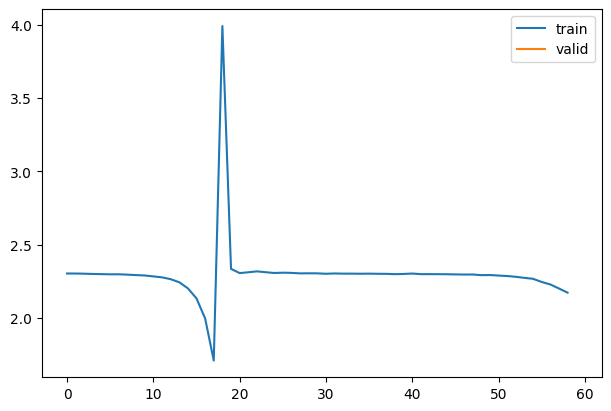

In [53]:
# =====================================================
# USING HOOKSCALLBACK
# =====================================================

# Create a callback that hooks only Conv2d layers
# lambda m: isinstance(m, nn.Conv2d) filters for Conv2d modules
hc = HooksCallback(
    append_stats, 
    mod_filter=lambda m: isinstance(m, nn.Conv2d)
)

set_seed(1)
model = nn.Sequential(*cnn_layers())
fit(model, xtra_cbs=[hc])

accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


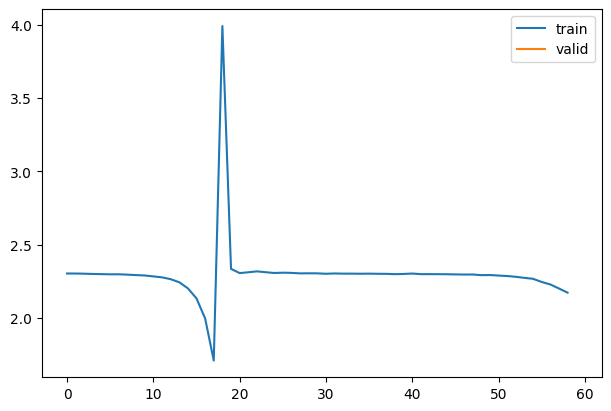

In [54]:
# Using `HooksCallback` — Every Line Explained

hc = HooksCallback(
    append_stats,
    # First argument: hookfunc = append_stats
    # This is the function that will be called every time a hooked layer
    # produces output during a forward pass. append_stats records the mean,
    # std, and histogram of the layer's activations onto the Hook object.
    # It is NOT called right now — it's just stored as hc.hookfunc for later.

    mod_filter=lambda m: isinstance(m, nn.Conv2d)
    # Second argument: mod_filter — a function that decides WHICH layers to hook.
    #
    # "lambda m:" defines a small anonymous (unnamed) function that takes one
    # argument 'm', which will be a module (layer) from the model.
    #
    # "isinstance(m, nn.Conv2d)" returns True if 'm' is a Conv2d layer,
    # and False for everything else (ReLU, Sequential, Flatten, etc.).
    #
    # So this filter says: "only hook the Conv2d layers, ignore all others."
    #
    # This filter is NOT applied right now — there's no model yet to filter.
    # It's stored as hc.mod_filter and will be used later in before_fit
    # when the Learner provides the model.
    #
    # We didn't pass on_train, on_valid, or mods, so they use their defaults:
    #   on_train=True   → record stats during training
    #   on_valid=False  → don't record stats during validation
    #   mods=None       → auto-discover layers using mod_filter (not manual)
)
# At this point, hc is a HooksCallback object with configuration stored,
# but NO hooks have been created yet. hc.hooks does not exist.
# The object is just waiting to be plugged into a training run.


set_seed(1)
# Sets random seeds for reproducibility.
# torch.manual_seed(1), random.seed(1), np.random.seed(1) are all called.
# This ensures that every time you run this code, the model starts with
# the same random weights and the data is shuffled the same way,
# so you get identical results each time.


model = nn.Sequential(*cnn_layers())
# Creates the CNN model.
#
# cnn_layers() returns a list of 6 layers:
#   [conv(1,8,ks=5), conv(8,16), conv(16,32), conv(32,64), conv(64,10,act=False), nn.Flatten()]
#
# Each conv() call returns either:
#   nn.Sequential(nn.Conv2d(...), nn.ReLU())   when act=True  (first 4 layers)
#   nn.Conv2d(...)                              when act=False (5th layer)
#
# The * operator unpacks the list, so nn.Sequential(*cnn_layers()) is equivalent to:
#   nn.Sequential(
#       nn.Sequential(Conv2d(1→8), ReLU()),     # layer 0
#       nn.Sequential(Conv2d(8→16), ReLU()),    # layer 1
#       nn.Sequential(Conv2d(16→32), ReLU()),   # layer 2
#       nn.Sequential(Conv2d(32→64), ReLU()),   # layer 3
#       Conv2d(64→10),                          # layer 4 (no ReLU)
#       nn.Flatten()                            # layer 5
#   )
#
# Note: the model exists now, but hc still has no hooks.
# The hooks will be created when training starts.


fit(model, xtra_cbs=[hc])
# This is where everything comes together. Let's trace what happens:
#
# fit() is a helper function that creates a Learner and trains it:
#
#   def fit(model, epochs=1, xtra_cbs=None):
#       learn = Learner(model, dls, loss_func=F.cross_entropy, lr=0.6,
#                        cbs=cbs+fc.L(xtra_cbs))
#       learn.fit(epochs)
#       return learn
#
# xtra_cbs=[hc] passes our HooksCallback as an extra callback.
# fc.L(xtra_cbs) wraps it in a fastcore list (handles None gracefully).
# cbs+fc.L(xtra_cbs) combines the standard callbacks (TrainCB, DeviceCB,
# MetricsCB, ProgressCB) with our HooksCallback into one list.
#
# Then learn.fit(epochs) starts the training loop, which triggers:
#
# ┌─────────────────────────────────────────────────────────────────┐
# │ learn.fit(1)                                                    │
# │   │                                                             │
# │   ├─ learn.callback('before_fit')                               │
# │   │    ├─ DeviceCB.before_fit()  → moves model to GPU/CPU      │
# │   │    └─ HooksCallback.before_fit(learn)                       │
# │   │         │                                                   │
# │   │         │  self.mods is None, so auto-discover:             │
# │   │         │  mods = [all Conv2d layers found via mod_filter]  │
# │   │         │       = [Conv2d(1→8), Conv2d(8→16),              │
# │   │         │          Conv2d(16→32), Conv2d(32→64),           │
# │   │         │          Conv2d(64→10)]                           │
# │   │         │                                                   │
# │   │         │  self.hooks = Hooks(mods, partial(_hookfunc, learn))│
# │   │         │  → Creates 5 Hook objects, one per Conv2d layer   │
# │   │         │  → Each Hook registers a forward hook on its layer│
# │   │                                                             │
# │   ├─ TRAINING EPOCH                                             │
# │   │    for each batch:                                          │
# │   │      learn.callback('before_batch')  → moves batch to device│
# │   │      TrainCB.predict()                                      │
# │   │        → learn.preds = learn.model(images)                  │
# │   │        → forward pass runs through all layers               │
# │   │        → EACH Conv2d layer triggers its hook:               │
# │   │            _hookfunc checks: on_train=True, training=True   │
# │   │            → gate passes → append_stats(hook, mod, inp, outp)│
# │   │            → mean, std, histogram stored on hook.stats      │
# │   │      TrainCB.get_loss()                                     │
# │   │      TrainCB.backward()                                     │
# │   │      TrainCB.step()                                         │
# │   │      TrainCB.zero_grad()                                    │
# │   │                                                             │
# │   ├─ VALIDATION EPOCH                                           │
# │   │    for each batch:                                          │
# │   │      TrainCB.predict()                                      │
# │   │        → forward pass runs through all layers               │
# │   │        → EACH Conv2d layer triggers its hook:               │
# │   │            _hookfunc checks: on_valid=False, training=False │
# │   │            → gate FAILS → append_stats is NOT called        │
# │   │            → no stats recorded during validation            │
# │   │                                                             │
# │   └─ learn.callback('after_fit')                                │
# │        └─ HooksCallback.after_fit(learn)                        │
# │             └─ self.hooks.remove()                              │
# │                → removes all 5 hooks from their Conv2d layers   │
# │                → hooks no longer fire on forward passes         │
# │                → BUT hook.stats data is still accessible        │
# └─────────────────────────────────────────────────────────────────┘
#
# After fit() returns:
#   - hc.hooks still exists as a list of 5 Hook objects
#   - Each hook's .stats contains all the means, stds, and histograms
#     recorded during every training batch
#   - The hooks have been detached from the model (no longer recording)
#   - You can now access the data: hc.hooks[0].stats, or iterate with
#     for h in hc: h.stats[0] (means), h.stats[1] (stds), etc.

# Using `HooksCallback` — Every Line Explained

---

```python
hc = HooksCallback(
    append_stats,
    # First argument: hookfunc = append_stats
    # This is the function that will be called every time a hooked layer
    # produces output during a forward pass. append_stats records the mean,
    # std, and histogram of the layer's activations onto the Hook object.
    # It is NOT called right now — it's just stored as hc.hookfunc for later.

    mod_filter=lambda m: isinstance(m, nn.Conv2d)
    # Second argument: mod_filter — a function that decides WHICH layers to hook.
    #
    # "lambda m:" defines a small anonymous (unnamed) function that takes one
    # argument 'm', which will be a module (layer) from the model.
    #
    # "isinstance(m, nn.Conv2d)" returns True if 'm' is a Conv2d layer,
    # and False for everything else (ReLU, Sequential, Flatten, etc.).
    #
    # So this filter says: "only hook the Conv2d layers, ignore all others."
    #
    # This filter is NOT applied right now — there's no model yet to filter.
    # It's stored as hc.mod_filter and will be used later in before_fit
    # when the Learner provides the model.
    #
    # We didn't pass on_train, on_valid, or mods, so they use their defaults:
    #   on_train=True   → record stats during training
    #   on_valid=False  → don't record stats during validation
    #   mods=None       → auto-discover layers using mod_filter (not manual)
)
# At this point, hc is a HooksCallback object with configuration stored,
# but NO hooks have been created yet. hc.hooks does not exist.
# The object is just waiting to be plugged into a training run.


set_seed(1)
# Sets random seeds for reproducibility.
# torch.manual_seed(1), random.seed(1), np.random.seed(1) are all called.
# This ensures that every time you run this code, the model starts with
# the same random weights and the data is shuffled the same way,
# so you get identical results each time.


model = nn.Sequential(*cnn_layers())
# Creates the CNN model.
#
# cnn_layers() returns a list of 6 layers:
#   [conv(1,8,ks=5), conv(8,16), conv(16,32), conv(32,64), conv(64,10,act=False), nn.Flatten()]
#
# Each conv() call returns either:
#   nn.Sequential(nn.Conv2d(...), nn.ReLU())   when act=True  (first 4 layers)
#   nn.Conv2d(...)                              when act=False (5th layer)
#
# The * operator unpacks the list, so nn.Sequential(*cnn_layers()) is equivalent to:
#   nn.Sequential(
#       nn.Sequential(Conv2d(1→8), ReLU()),     # layer 0
#       nn.Sequential(Conv2d(8→16), ReLU()),    # layer 1
#       nn.Sequential(Conv2d(16→32), ReLU()),   # layer 2
#       nn.Sequential(Conv2d(32→64), ReLU()),   # layer 3
#       Conv2d(64→10),                          # layer 4 (no ReLU)
#       nn.Flatten()                            # layer 5
#   )
#
# Note: the model exists now, but hc still has no hooks.
# The hooks will be created when training starts.


fit(model, xtra_cbs=[hc])
# This is where everything comes together. Let's trace what happens:
#
# fit() is a helper function that creates a Learner and trains it:
#
#   def fit(model, epochs=1, xtra_cbs=None):
#       learn = Learner(model, dls, loss_func=F.cross_entropy, lr=0.6,
#                        cbs=cbs+fc.L(xtra_cbs))
#       learn.fit(epochs)
#       return learn
#
# xtra_cbs=[hc] passes our HooksCallback as an extra callback.
# fc.L(xtra_cbs) wraps it in a fastcore list (handles None gracefully).
# cbs+fc.L(xtra_cbs) combines the standard callbacks (TrainCB, DeviceCB,
# MetricsCB, ProgressCB) with our HooksCallback into one list.
#
# Then learn.fit(epochs) starts the training loop, which triggers:
#
# ┌─────────────────────────────────────────────────────────────────┐
# │ learn.fit(1)                                                    │
# │   │                                                             │
# │   ├─ learn.callback('before_fit')                               │
# │   │    ├─ DeviceCB.before_fit()  → moves model to GPU/CPU      │
# │   │    └─ HooksCallback.before_fit(learn)                       │
# │   │         │                                                   │
# │   │         │  self.mods is None, so auto-discover:             │
# │   │         │  mods = [all Conv2d layers found via mod_filter]  │
# │   │         │       = [Conv2d(1→8), Conv2d(8→16),              │
# │   │         │          Conv2d(16→32), Conv2d(32→64),           │
# │   │         │          Conv2d(64→10)]                           │
# │   │         │                                                   │
# │   │         │  self.hooks = Hooks(mods, partial(_hookfunc, learn))│
# │   │         │  → Creates 5 Hook objects, one per Conv2d layer   │
# │   │         │  → Each Hook registers a forward hook on its layer│
# │   │                                                             │
# │   ├─ TRAINING EPOCH                                             │
# │   │    for each batch:                                          │
# │   │      learn.callback('before_batch')  → moves batch to device│
# │   │      TrainCB.predict()                                      │
# │   │        → learn.preds = learn.model(images)                  │
# │   │        → forward pass runs through all layers               │
# │   │        → EACH Conv2d layer triggers its hook:               │
# │   │            _hookfunc checks: on_train=True, training=True   │
# │   │            → gate passes → append_stats(hook, mod, inp, outp)│
# │   │            → mean, std, histogram stored on hook.stats      │
# │   │      TrainCB.get_loss()                                     │
# │   │      TrainCB.backward()                                     │
# │   │      TrainCB.step()                                         │
# │   │      TrainCB.zero_grad()                                    │
# │   │                                                             │
# │   ├─ VALIDATION EPOCH                                           │
# │   │    for each batch:                                          │
# │   │      TrainCB.predict()                                      │
# │   │        → forward pass runs through all layers               │
# │   │        → EACH Conv2d layer triggers its hook:               │
# │   │            _hookfunc checks: on_valid=False, training=False │
# │   │            → gate FAILS → append_stats is NOT called        │
# │   │            → no stats recorded during validation            │
# │   │                                                             │
# │   └─ learn.callback('after_fit')                                │
# │        └─ HooksCallback.after_fit(learn)                        │
# │             └─ self.hooks.remove()                              │
# │                → removes all 5 hooks from their Conv2d layers   │
# │                → hooks no longer fire on forward passes         │
# │                → BUT hook.stats data is still accessible        │
# └─────────────────────────────────────────────────────────────────┘
#
# After fit() returns:
#   - hc.hooks still exists as a list of 5 Hook objects
#   - Each hook's .stats contains all the means, stds, and histograms
#     recorded during every training batch
#   - The hooks have been detached from the model (no longer recording)
#   - You can now access the data: hc.hooks[0].stats, or iterate with
#     for h in hc: h.stats[0] (means), h.stats[1] (stds), etc.
```

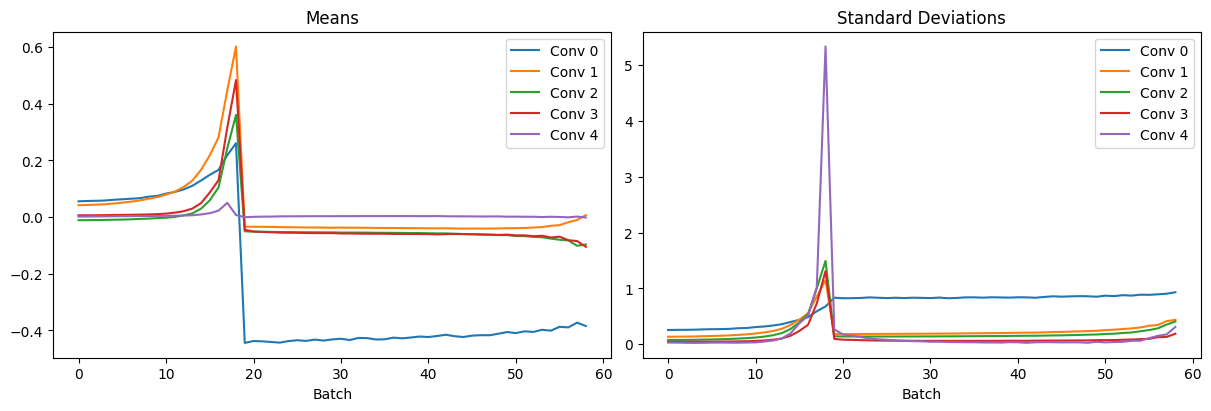

In [55]:
# Plot the results
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for i, h in enumerate(hc):
    axs[0].plot(h.stats[0], label=f'Conv {i}')
    axs[1].plot(h.stats[1], label=f'Conv {i}')

axs[0].set_title('Means')
axs[0].set_xlabel('Batch')
axs[0].legend()

axs[1].set_title('Standard Deviations')
axs[1].set_xlabel('Batch')
axs[1].legend()

---

# Part 8: Histograms for Deeper Analysis

---

Mean and std are useful, but they don't tell the whole story. **Histograms** show the full distribution of activations.

## Why Histograms?

Consider two distributions with the same mean and std:
- **Normal**: Values spread smoothly around mean
- **Bimodal**: Values clustered at two extremes

These behave very differently but have identical summary statistics!

## 🎮 Interactive: the dead-ReLU detector

Histograms let us spot **dead ReLUs** — neurons whose pre-activation is almost always negative, so `max(0, x)` outputs `0` every time and they stop learning. Drag the input **mean**, **spread**, and **bias** to push the distribution negative and watch the *dead fraction* (the count in histogram bin 0) climb. This is precisely the quantity `dead_chart()` plots per layer.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/dead_relu_detector.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. Dead-ReLU detector: watch the dead fraction climb.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/dead_relu_detector.html", height="560px")

In [ ]:
# =====================================================
# UPDATED APPEND_STATS WITH HISTOGRAMS
# =====================================================

def append_stats(hook, mod, inp, outp):
    """
    Hook function that stores mean, std, AND histogram.
    
    The histogram is computed with:
    - 40 bins
    - Range 0 to 10
    - Applied to absolute values (since ReLU outputs are non-negative)
    
    hook.stats = (means_list, stds_list, histograms_list)
    """
    if not hasattr(hook, 'stats'):
        hook.stats = ([], [], [])  # (means, stds, histograms)
    
    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean().item())
    hook.stats[1].append(acts.std().item())
    
    # Histogram: 40 bins from 0 to 10
    # .abs() because we want magnitude
    # .histc() computes histogram
    hook.stats[2].append(acts.abs().histc(40, 0, 10))

accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


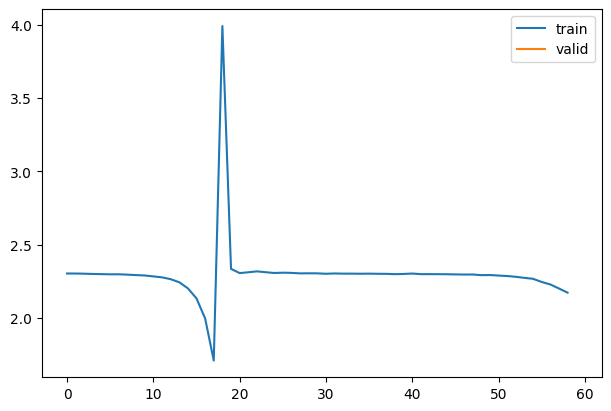

In [58]:
# Train with the new hook function
set_seed(1)
model = nn.Sequential(*cnn_layers())
hc = HooksCallback(append_stats, mod_filter=lambda m: isinstance(m, nn.Conv2d))
fit(model, xtra_cbs=[hc])

In [ ]:
# =====================================================
# HELPER FUNCTIONS FOR HISTOGRAM VISUALIZATION
# =====================================================

def get_hist(h):
    """
    Get histogram data as a 2D image for visualization.
    
    Arguments:
        h - A hook with stats[2] containing histogram tensors
    
    Returns:
        A 2D tensor where:
        - Rows = histogram bins (activation magnitude)
        - Columns = batches (time)
        - Values = log(count + 1) for better visualization
    
    The .log1p() (log(x+1)) helps visualize small counts.
    """
    # Stack all histograms: (n_batches, 40) -> (40, n_batches) after .t()
    return torch.stack(h.stats[2]).t().float().log1p()

def get_min(h):
    """
    Get the fraction of activations in the smallest bin (near zero).
    
    This helps detect "dead" ReLUs - neurons that always output 0.
    
    Returns:
        A 1D tensor with the fraction of near-zero activations per batch.
    """
    h1 = torch.stack(h.stats[2]).t().float()
    # h1[0] is the first bin (values near 0)
    # h1.sum(0) is the total count per batch
    return h1[0] / h1.sum(0)

/tmp/ipykernel_3906/1680346331.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


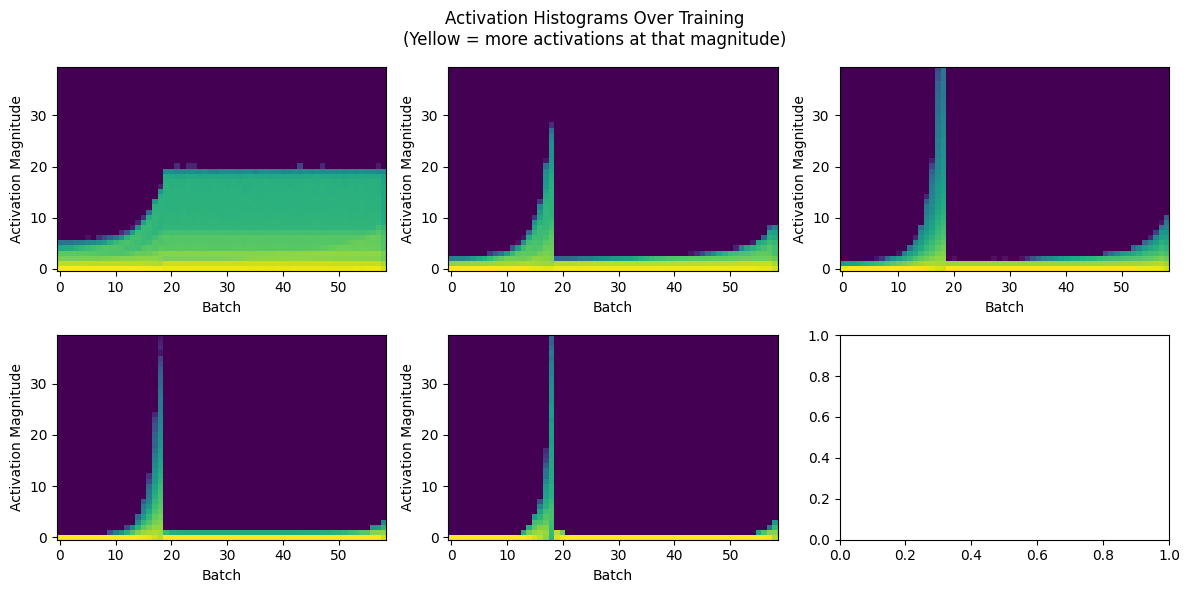

In [60]:
# =====================================================
# VISUALIZE ACTIVATION HISTOGRAMS
# =====================================================

fig, axes = get_grid(len(hc), figsize=(12, 6))

for ax, h in zip(axes.flatten(), hc):
    # Show histogram as a color image
    # origin='lower' puts bin 0 at bottom
    im = ax.imshow(get_hist(h).numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax.set_xlabel('Batch')
    ax.set_ylabel('Activation Magnitude')

plt.suptitle('Activation Histograms Over Training\n(Yellow = more activations at that magnitude)', fontsize=12)
plt.tight_layout()

**How to read these plots:**

- **X-axis**: Training batches (time)
- **Y-axis**: Activation magnitude (0 at bottom, 10 at top)
- **Color**: How many activations have that magnitude (yellow = more)

**What to look for:**

| Pattern | What it means |
|---------|---------------|
| All yellow at bottom | Many zeros (dead ReLUs!) |
| Yellow spreading up | Activations getting larger |
| Yellow band in middle | Healthy, stable activations |
| Yellow at top | Exploding activations |

/tmp/ipykernel_3906/1510966853.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


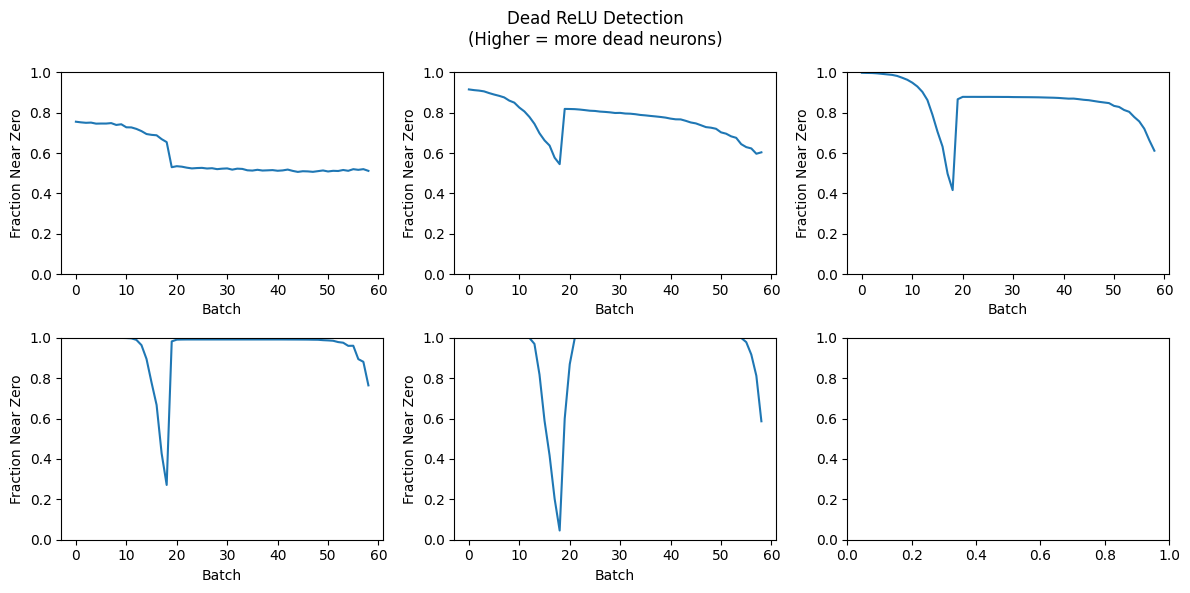

In [61]:
# =====================================================
# DEAD RELU DETECTION
# =====================================================

fig, axes = get_grid(len(hc), figsize=(12, 6))

for ax, h in zip(axes.flatten(), hc):
    # Plot fraction of near-zero activations over time
    ax.plot(get_min(h).numpy())
    ax.set_ylim(0, 1)
    ax.set_xlabel('Batch')
    ax.set_ylabel('Fraction Near Zero')

plt.suptitle('Dead ReLU Detection\n(Higher = more dead neurons)', fontsize=12)
plt.tight_layout()

**Interpretation:**
- If the fraction near zero is high and stable → those neurons are "dead"
- Dead neurons don't learn because gradient = 0 when ReLU input < 0
- This can happen with:
  - Too high learning rate
  - Bad initialization
  - Very negative biases

---

---

# Part 9: ActivationStats Class

---

Let's wrap everything into a convenient class.

In [ ]:
#|export
# This is a special comment used by nbdev (a tool for creating Python libraries
# from notebooks). It tells nbdev: "include this code in the exported library module."
# You can ignore this line — it has no effect on how the code runs in the notebook.


class ActivationStats(HooksCallback):
    # ActivationStats is a new class that INHERITS from HooksCallback.
    #
    # What does inheritance mean here?
    # ─────────────────────────────────
    # ActivationStats gets ALL the functionality of HooksCallback for free:
    #   - before_fit()   → auto-discovers Conv2d layers and creates hooks
    #   - after_fit()    → removes hooks after training
    #   - _hookfunc()    → gates recording by train/valid mode
    #   - __iter__()     → lets you loop over hooks with "for h in self"
    #   - __len__()      → lets you call len(self) to count hooks
    #
    # ActivationStats then ADDS convenience methods on top:
    #   - color_dim()    → visualize activation histograms as color images
    #   - dead_chart()   → plot fraction of near-zero activations (dead ReLUs)
    #   - plot_stats()   → plot means and standard deviations over training
    #
    # Think of it as: HooksCallback is the engine, ActivationStats is the dashboard.
    # HooksCallback handles all the plumbing (creating hooks, recording data, cleanup).
    # ActivationStats just provides pretty visualizations of the collected data.
    #
    # The inheritance chain is:
    #   Callback  →  HooksCallback  →  ActivationStats
    #     │              │                  │
    #     │              │                  └─ Adds visualization methods
    #     │              └─ Adds hook lifecycle, module discovery, train/valid gating
    #     └─ Base class that plugs into the Learner's training loop


    def __init__(self, mod_filter=fc.noop): super().__init__(append_stats, mod_filter)
    # This is the constructor — it runs when you create an instance:
    #   astats = ActivationStats(mod_filter=lambda m: isinstance(m, nn.Conv2d))
    #
    # It takes ONE argument:
    #
    #   mod_filter (optional, default=fc.noop):
    #     A function that decides WHICH layers in the model to monitor.
    #     Example: lambda m: isinstance(m, nn.Conv2d)  →  "only monitor Conv2d layers"
    #     The default fc.noop does nothing (returns None), meaning no layers pass.
    #     In practice, you almost always provide your own filter.
    #
    # The body is just: super().__init__(append_stats, mod_filter)
    #
    # super() refers to the PARENT class, which is HooksCallback.
    # So this calls:
    #   HooksCallback.__init__(self, hookfunc=append_stats, mod_filter=mod_filter)
    #
    # This is the KEY SIMPLIFICATION that ActivationStats provides:
    #
    #   BEFORE (using HooksCallback directly):
    #     hc = HooksCallback(append_stats, mod_filter=lambda m: isinstance(m, nn.Conv2d))
    #                        ^^^^^^^^^^^^
    #                        You had to remember to pass append_stats every time
    #
    #   AFTER (using ActivationStats):
    #     astats = ActivationStats(mod_filter=lambda m: isinstance(m, nn.Conv2d))
    #                              ← append_stats is automatically provided!
    #
    # ActivationStats HARDCODES append_stats as the hook function.
    # You never need to think about which function to pass — the class
    # always uses append_stats, which records means, stds, and histograms.
    #
    # After this constructor runs, the object has all the HooksCallback attributes:
    #   self.hookfunc   = append_stats        (what to record)
    #   self.mod_filter = the filter you gave  (which layers to monitor)
    #   self.on_train   = True                 (record during training)
    #   self.on_valid   = False                (skip validation)
    #   self.mods       = None                 (auto-discover layers)
    #   self.hooks      = doesn't exist yet    (created later in before_fit)


    def color_dim(self, figsize=(11,5)):
        # Visualize activation histograms as COLOR IMAGES — one image per hooked layer.
        #
        # This is the most informative visualization in the notebook. Each image shows
        # how the DISTRIBUTION of activations changes over the course of training.
        #
        # Arguments:
        #   figsize (optional, default=(11,5)):
        #     The size of the entire figure in inches, as (width, height).
        #     11 inches wide, 5 inches tall gives a good landscape layout.
        #
        # This method can ONLY be called AFTER training, because the hooks need
        # to have recorded data first. If you call it before fit(), there's no data.

        fig,axes = get_grid(len(self), figsize=figsize)
        # get_grid() is a helper function defined earlier in the notebook.
        # It creates a GRID of subplots (small individual plots arranged in rows/columns).
        #
        # len(self) returns the number of hooks (= number of hooked layers).
        #   - len(self) calls self.__len__(), inherited from HooksCallback
        #   - which returns len(self.hooks), the number of Hook objects
        #   - For our CNN with 5 Conv2d layers, len(self) = 5
        #
        # get_grid(5, figsize=(11,5)) creates a figure with 5 subplots arranged
        # in a grid (e.g., 2 rows × 3 columns, with one subplot left empty).
        #
        # Returns:
        #   fig  — the overall Figure object (the whole canvas)
        #   axes — a 2D numpy array of Axes objects (individual subplots)
        #          e.g., for a 2×3 grid: axes has shape (2, 3)

        for ax,h in zip(axes.flat, self):
            # This loops over EACH subplot and its corresponding hook SIMULTANEOUSLY.
            #
            # axes.flat:
            #   axes is a 2D numpy array (e.g., shape (2,3) for a 2×3 grid).
            #   .flat is a numpy property that creates a 1D iterator over all elements.
            #   So axes.flat yields: axes[0,0], axes[0,1], axes[0,2], axes[1,0], ...
            #   Each element is a matplotlib Axes object (one subplot to draw on).
            #
            # self:
            #   Iterating over self (an ActivationStats object) works because
            #   ActivationStats inherits __iter__ from HooksCallback, which does:
            #     def __iter__(self): return iter(self.hooks)
            #   So "for h in self" yields individual Hook objects, one per Conv2d layer.
            #
            # zip(axes.flat, self):
            #   Pairs up each Axes with its corresponding Hook:
            #     (axes[0,0], Hook_for_Conv2d_1→8)
            #     (axes[0,1], Hook_for_Conv2d_8→16)
            #     (axes[0,2], Hook_for_Conv2d_16→32)
            #     (axes[1,0], Hook_for_Conv2d_32→64)
            #     (axes[1,1], Hook_for_Conv2d_64→10)
            #   If the grid has more subplots than hooks (e.g., 6 subplots for 5 hooks),
            #   zip stops at the shorter one, leaving the extra subplot empty.

            show_image(get_hist(h), ax, origin='lower')
            # This draws the histogram data as a color image on the subplot.
            #
            # INNER CALL: get_hist(h)
            #   get_hist() is a helper function defined in Part 8 of the notebook:
            #
            #     def get_hist(h):
            #         return torch.stack(h.stats[2]).t().float().log1p()
            #
            #   What it does, step by step:
            #     h.stats[2]  →  a list of histogram tensors, one per training batch
            #                    Each tensor has 40 values (40 bins, range 0 to 10)
            #                    Example: [hist_batch0, hist_batch1, ..., hist_batchN]
            #
            #     torch.stack(h.stats[2])  →  stacks them into a 2D tensor
            #                                 Shape: (num_batches, 40)
            #                                 Each ROW is one batch's histogram
            #
            #     .t()  →  transpose: (40, num_batches)
            #              Now each ROW is one bin, each COLUMN is one batch
            #              This orients the image so bins are on the Y-axis (vertical)
            #              and training time is on the X-axis (horizontal)
            #
            #     .float()  →  convert to float (needed for log computation)
            #
            #     .log1p()  →  applies log(x + 1) to every value
            #                  Why? Raw histogram counts can vary enormously (e.g., 0 to 50000).
            #                  log1p compresses large values, making small counts visible.
            #                  The "+1" prevents log(0) which would be -infinity.
            #
            #   The result is a 2D tensor of shape (40, num_batches) — like a 40-pixel-tall
            #   image where each column is one training batch. This is what gets displayed.
            #
            # OUTER CALL: show_image(image, ax, origin='lower')
            #   show_image() is a helper function defined in Part 1:
            #     - Takes a 2D tensor/array and displays it as an image using ax.imshow()
            #     - ax = the specific subplot to draw on
            #     - origin='lower' means:
            #         The FIRST row of the array (bin 0 = activations near zero)
            #         is drawn at the BOTTOM of the image.
            #         Without this, matplotlib puts row 0 at the TOP by default.
            #         We want low activation values at the bottom and high at the top,
            #         like a normal graph, so origin='lower' is essential.
            #
            # HOW TO READ THE RESULTING IMAGES:
            # ─────────────────────────────────
            #   X-axis (horizontal): Training batches (time flows left to right)
            #   Y-axis (vertical):   Activation magnitude (0 at bottom, 10 at top)
            #   Color:               How many activations have that magnitude
            #                        Bright/yellow = many activations at that magnitude
            #                        Dark/purple = few or no activations at that magnitude
            #
            #   HEALTHY pattern:  A bright band in the lower-middle region that stays
            #                     stable over training — activations are moderate and consistent.
            #
            #   UNHEALTHY patterns:
            #     - Bright band at very bottom → many near-zero activations (dead ReLUs)
            #     - Bright band moving upward  → activations are exploding
            #     - Bright band shrinking to 0 → activations are vanishing
            #     - All brightness at bottom   → most neurons are dead


    def dead_chart(self, figsize=(11,5)):
        # Plot the FRACTION OF NEAR-ZERO ACTIVATIONS over training — one plot per layer.
        #
        # This is the "dead ReLU detector." A dead ReLU is a neuron whose output is
        # always zero (or very close to zero), meaning it has stopped contributing to
        # the network's learning. Dead ReLUs happen when the input to ReLU is always
        # negative, so ReLU(x) = max(0, x) = 0 for every input in the batch.
        #
        # Arguments:
        #   figsize (optional, default=(11,5)):
        #     The size of the entire figure in inches (width, height).

        fig,axes = get_grid(len(self), figsize=figsize)
        # Same as in color_dim(): create a grid of subplots.
        # len(self) = number of hooked layers (5 for our CNN).
        # fig = the overall figure canvas.
        # axes = a 2D numpy array of subplot Axes objects.

        for ax,h in zip(axes.flatten(), self):
            # Loop over each subplot and its corresponding hook simultaneously.
            #
            # axes.flatten():
            #   Converts the 2D array of axes into a 1D array.
            #   .flatten() is a numpy method that returns a COPY as a 1D array.
            #   Note: In color_dim() above, we used axes.flat (an iterator).
            #   Both work the same way here — they produce a flat sequence of axes.
            #   The difference is minor: .flat is a view/iterator, .flatten() is a copy.
            #   For this purpose, both are fine.
            #
            # self:
            #   Iterating yields Hook objects (same as in color_dim()).

            ax.plot(get_min(h))
            # INNER CALL: get_min(h)
            #   get_min() is a helper function defined in Part 8 of the notebook:
            #
            #     def get_min(h):
            #         h1 = torch.stack(h.stats[2]).t().float()
            #         return h1[0] / h1.sum(0)
            #
            #   What it does, step by step:
            #     h.stats[2]                → list of histogram tensors (one per batch)
            #     torch.stack(h.stats[2])   → shape (num_batches, 40)
            #     .t()                      → shape (40, num_batches)  [bins × batches]
            #     .float()                  → convert to float for division
            #
            #     h1[0]       → the FIRST row = the first histogram bin
            #                   This bin counts activations with magnitude closest to 0.
            #                   Shape: (num_batches,) — one count per batch.
            #
            #     h1.sum(0)   → sum along axis 0 (sum all 40 bins for each batch)
            #                   This gives the TOTAL number of activations per batch.
            #                   Shape: (num_batches,)
            #
            #     h1[0] / h1.sum(0)  → FRACTION of activations that are near zero
            #                          Values range from 0.0 (no dead neurons) to 1.0 (all dead)
            #                          Shape: (num_batches,)
            #
            #   Returns: a 1D tensor with one value per training batch.
            #
            # OUTER CALL: ax.plot(get_min(h))
            #   ax.plot() draws a LINE CHART on the subplot.
            #   X-axis: batch index (0, 1, 2, ...) — assigned automatically
            #   Y-axis: the fraction of near-zero activations
            #   This shows how the "deadness" of each layer evolves during training.

            ax.set_ylim(0,1)
            # Fix the Y-axis range from 0 to 1 for ALL subplots.
            #
            # Why? The fraction is always between 0 and 1 (it's a ratio),
            # so fixing the axis makes all layers directly comparable.
            # Without this, matplotlib would auto-scale each subplot independently,
            # making it hard to compare which layers have more dead neurons.
            #
            # HOW TO READ THESE PLOTS:
            # ────────────────────────
            #   Y near 0   → very few activations are near zero → healthy layer
            #   Y near 0.5 → half the activations are near zero → concerning
            #   Y near 1   → almost all activations are near zero → layer is dead!
            #
            #   A line that starts low and stays low → layer is healthy throughout
            #   A line that rises over training → neurons are dying during training
            #   A line that starts high → bad initialization (too many neurons start dead)


    def plot_stats(self, figsize=(10,4)):
        # Plot MEAN and STANDARD DEVIATION of activations over training.
        #
        # This creates TWO side-by-side plots:
        #   Left plot:  Mean activation per layer over training batches
        #   Right plot: Standard deviation per layer over training batches
        #
        # These are the simplest summary statistics. They tell you:
        #   - Means: Where is the "center" of each layer's activations?
        #   - Stds:  How "spread out" are the activations?
        #
        # Arguments:
        #   figsize (optional, default=(10,4)):
        #     The size of the entire figure in inches (width, height).
        #     10 wide × 4 tall gives a nice wide layout for two side-by-side plots.

        fig,axs = plt.subplots(1,2, figsize=figsize)
        # plt.subplots(1, 2) creates a figure with 1 ROW and 2 COLUMNS of subplots.
        # This gives us exactly two subplots side by side.
        #
        # Returns:
        #   fig — the overall Figure object
        #   axs — a 1D numpy array with 2 Axes objects: [left_subplot, right_subplot]
        #         axs[0] = left subplot (for means)
        #         axs[1] = right subplot (for stds)
        #
        # Note: Unlike color_dim() and dead_chart() which use get_grid() for a
        # multi-subplot grid (one per layer), here we use plt.subplots() directly
        # because we want exactly 2 subplots — all layers are plotted on the SAME
        # subplot as separate lines, rather than each layer getting its own subplot.

        for h in self:
            # Loop over each Hook object (one per Conv2d layer).
            # self.__iter__() yields Hook objects via HooksCallback.__iter__().
            #
            # For our 5-layer CNN, this loops 5 times:
            #   h = Hook for Conv2d(1→8)      (first iteration)
            #   h = Hook for Conv2d(8→16)     (second iteration)
            #   h = Hook for Conv2d(16→32)    (third iteration)
            #   h = Hook for Conv2d(32→64)    (fourth iteration)
            #   h = Hook for Conv2d(64→10)    (fifth iteration)

            for i in 0,1: axs[i].plot(h.stats[i])
            # This inner loop runs TWICE: once for i=0 and once for i=1.
            #
            # "for i in 0,1" is a Python shorthand. The expression "0,1" creates
            # a tuple (0, 1), and the for loop iterates over its elements.
            # It's equivalent to: for i in (0, 1):
            #
            # When i=0:
            #   axs[0].plot(h.stats[0])
            #   axs[0] is the LEFT subplot (means)
            #   h.stats[0] is the list of MEAN values for this layer
            #     — one mean per training batch, e.g., [0.12, 0.15, 0.11, ...]
            #   .plot() draws this as a line on the left subplot.
            #
            # When i=1:
            #   axs[1].plot(h.stats[1])
            #   axs[1] is the RIGHT subplot (stds)
            #   h.stats[1] is the list of STD values for this layer
            #     — one std per training batch, e.g., [0.45, 0.42, 0.44, ...]
            #   .plot() draws this as a line on the right subplot.
            #
            # Since the outer loop runs once per layer, and each iteration adds a
            # line to both subplots, the final result is:
            #   Left subplot:  5 lines (one per Conv2d layer) showing means over time
            #   Right subplot: 5 lines (one per Conv2d layer) showing stds over time
            #
            # Each line gets a different color automatically (matplotlib's default cycle).

        axs[0].set_title('Means')
        # Add the title "Means" to the left subplot.

        axs[1].set_title('Stdevs')
        # Add the title "Stdevs" (standard deviations) to the right subplot.

        plt.legend(fc.L.range(self))
        # Add a LEGEND to identify which colored line belongs to which layer.
        #
        # fc.L.range(self):
        #   fc.L is a fastcore enhanced list class.
        #   fc.L.range(self) creates a list of integers from 0 to len(self)-1.
        #   len(self) = 5 (number of hooked Conv2d layers).
        #   So fc.L.range(self) returns something like: [0, 1, 2, 3, 4]
        #
        #   These integers become the legend labels. The legend will show:
        #     ── 0  (line for Conv2d layer 0: 1→8 channels)
        #     ── 1  (line for Conv2d layer 1: 8→16 channels)
        #     ── 2  (line for Conv2d layer 2: 16→32 channels)
        #     ── 3  (line for Conv2d layer 3: 32→64 channels)
        #     ── 4  (line for Conv2d layer 4: 64→10 channels)
        #
        # plt.legend() adds the legend to the LAST active subplot (the right one),
        # but since both subplots share the same lines (same number of layers,
        # same color cycle), the legend applies visually to both plots.
        #
        # HOW TO READ THESE PLOTS:
        # ────────────────────────
        # MEANS (left):
        #   - All lines near 0 and stable     → healthy (activations are centered)
        #   - Lines drifting upward            → activations growing (possible explosion)
        #   - Lines collapsing to 0            → activations vanishing
        #   - Big differences between layers   → inconsistent initialization
        #
        # STDS (right):
        #   - All lines similar and stable     → healthy (consistent spread)
        #   - Lines growing over time          → activations spreading out (exploding)
        #   - Lines shrinking toward 0         → activations collapsing (vanishing)
        #   - Later layers much smaller        → signal is dying as it passes through


# ═══════════════════════════════════════════════════════════════════════════════
# HOW THIS CLASS IS USED IN THE NOTEBOOK
# ═══════════════════════════════════════════════════════════════════════════════
#
# Step 1: Create an ActivationStats callback
#
#   astats = ActivationStats(mod_filter=lambda m: isinstance(m, nn.Conv2d))
#   # This creates the monitoring callback. No hooks exist yet.
#   # It just stores: "I want to monitor Conv2d layers using append_stats."
#
#
# Step 2: Train the model with this callback
#
#   set_seed(1)
#   model = nn.Sequential(*cnn_layers())
#   fit(model, xtra_cbs=[astats])
#   #
#   # During training, the following happens automatically:
#   #   before_fit → discovers 5 Conv2d layers, creates hooks on each
#   #   each training batch → hooks fire, append_stats records mean/std/histogram
#   #   after_fit → hooks are removed (but recorded data remains)
#
#
# Step 3: Visualize the collected data (call any of the three methods)
#
#   astats.color_dim()    # Show activation distribution heatmaps
#   astats.dead_chart()   # Show dead ReLU fractions
#   astats.plot_stats()   # Show mean and std line plots
#
#
# COMPARED TO USING HooksCallback DIRECTLY:
# ──────────────────────────────────────────
#
#   # OLD WAY (HooksCallback):
#   hc = HooksCallback(append_stats, mod_filter=lambda m: isinstance(m, nn.Conv2d))
#   fit(model, xtra_cbs=[hc])
#   # Then you'd have to manually write the plotting code every time:
#   fig, axes = get_grid(len(hc), figsize=(11,5))
#   for ax, h in zip(axes.flat, hc):
#       show_image(get_hist(h), ax, origin='lower')
#
#   # NEW WAY (ActivationStats):
#   astats = ActivationStats(mod_filter=lambda m: isinstance(m, nn.Conv2d))
#   fit(model, xtra_cbs=[astats])
#   astats.color_dim()   # One line does it all!
#
# ActivationStats is the final, most user-friendly layer in the class hierarchy:
#
#   Hook           → manages ONE hook on ONE layer
#   Hooks          → manages MANY hooks with automatic cleanup
#   HooksCallback  → integrates hooks with the Learner's training loop
#   ActivationStats → adds visualization methods for instant diagnostics
#
# Each class adds convenience on top of the previous one, so by the time you
# reach ActivationStats, monitoring your neural network is as simple as:
#   1. Create it
#   2. Pass it to fit()
#   3. Call .color_dim(), .dead_chart(), or .plot_stats()

## 🎮 Interactive (3D): the activation landscape

Same data as `color_dim`, lifted into 3D. Each ridge is one batch's distribution; **height** is the count at that magnitude. **Drag to rotate**, scroll to zoom, and switch regimes to feel the difference: a healthy steady ridge, a tall wall of dead neurons at magnitude≈0, or an exploding ridge marching to the right.

*(Loads three.js from a CDN, so it needs an internet connection. If offline, the 2D explorer above shows the same idea.)*

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/activation_stats_3d.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. 3D activation landscape (color_dim lifted into 3D).
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/activation_stats_3d.html", height="470px")

# How Does `for h in hc` Work?

## The Question

Given this code from the notebook:

```python
hc = HooksCallback(append_stats, mod_filter=lambda m: isinstance(m, nn.Conv2d))

set_seed(1)
model = nn.Sequential(*cnn_layers())
fit(model, xtra_cbs=[hc])

# Later, when plotting:
for i, h in enumerate(hc):
    axs[0].plot(h.stats[0], label=f'Conv {i}')
    axs[1].plot(h.stats[1], label=f'Conv {i}')
```

How can we loop over `hc`? What are the different values of `h`?

---

## Short Answer

Each `h` is a **`Hook` object** — one per `nn.Conv2d` layer in the model. Since `cnn_layers()` creates 5 Conv2d layers (but only 4 have ReLU and pass the filter during training with activations), iterating over `hc` yields individual `Hook` objects, each holding the activation statistics for one convolutional layer.

---

## The Full Chain — Traced Through the Notebook's Actual Code

### Step 1: `HooksCallback.__iter__` Makes `hc` Iterable

From **Cell 40** of the notebook:

```python
class HooksCallback(Callback):
    # ...
    def __iter__(self):
        """Iterate over hooks."""
        return iter(self.hooks)
```

When Python encounters `for h in hc`, it calls `hc.__iter__()`, which returns `iter(self.hooks)`. So the question becomes: **what is `self.hooks` and what does it contain?**

---

### Step 2: `self.hooks` Is Created in `before_fit`

From the same class in **Cell 40**:

```python
def before_fit(self, learn):
    """Attach hooks to filtered modules."""
    if self.mods:
        mods = self.mods
    else:
        # Filter modules using mod_filter
        mods = [m for m in learn.model.modules() if self.mod_filter(m)]
    # Create hooks, passing learn to the hook function
    self.hooks = Hooks(mods, partial(self._hookfunc, learn))
```

Two things happen here:

1. **`mods`** is built by filtering `learn.model.modules()` with `self.mod_filter`. Since we set `mod_filter=lambda m: isinstance(m, nn.Conv2d)`, this collects **only the `nn.Conv2d` layers** from the model.

2. **`self.hooks`** is assigned a `Hooks(mods, ...)` object — a `Hooks` instance constructed from those filtered modules.

So `self.hooks` is a `Hooks` object. Now the question is: **what does iterating over a `Hooks` object yield?**

---

### Step 3: The `Hooks` Class — A List of `Hook` Objects

From **Cell 37** of the notebook:

```python
class Hooks(list):
    def __init__(self, ms, f):
        """
        Create hooks for multiple modules.

        Arguments:
            ms - Iterable of modules to hook
            f  - Hook function
        """
        super().__init__([Hook(m, f) for m in ms])
    # ...
```

**This is the critical line that answers the question.** The `Hooks` class:

- **Inherits from `list`** — so it's literally a Python list
- In `__init__`, it calls `super().__init__([Hook(m, f) for m in ms])` — this populates itself with a **list comprehension that creates one `Hook` object per module**

Since `Hooks` inherits from `list`, iterating over it yields the individual items in the list — which are `Hook` objects. There is no custom `__iter__` needed; Python's built-in `list.__iter__` handles it.

---

### Step 4: The `Hook` Class — What Each `h` Actually Is

From **Cell 29** of the notebook:

```python
class Hook:
    def __init__(self, m, f):
        # Register the hook, passing self as first argument to f
        self.hook = m.register_forward_hook(partial(f, self))

    def remove(self):
        """Remove the hook from the module."""
        self.hook.remove()

    def __del__(self):
        self.remove()
```

Each `Hook` object:
- Wraps a **single PyTorch forward hook** on a **single module**
- Passes `self` (the `Hook` instance) as the first argument to the hook function via `partial(f, self)`
- This means the hook function can **store data directly on the `Hook` object**

---

### Step 5: How Stats Get Stored on Each `Hook`

From **Cell 30** of the notebook:

```python
def append_stats(hook, mod, inp, outp):
    if not hasattr(hook, 'stats'):
        hook.stats = ([], [])  # (means, stds)

    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean().item())
    hook.stats[1].append(acts.std().item())
```

Every time a forward pass goes through a Conv2d layer:
1. PyTorch triggers the registered hook
2. `append_stats` is called with `hook` = the `Hook` object for that layer
3. It stores `(means_list, stds_list)` directly on `hook.stats`

So after training, each `Hook` has its own `.stats` attribute with the full history of means and stds **for that specific Conv2d layer**.

---

## The Complete Iteration Chain

```
for h in hc:
│
├─ Python calls: hc.__iter__()                    # HooksCallback (Cell 40)
│  └─ returns: iter(self.hooks)                    # self.hooks is a Hooks object
│
├─ Python calls: iter(self.hooks)                  # Hooks inherits from list (Cell 37)
│  └─ Hooks was initialized with:
│     super().__init__([Hook(m, f) for m in ms])   # A list of Hook objects!
│
└─ Yields on each iteration:
   Hook_0 (for Conv2d 1→8)    ← h.stats = ([mean1, mean2, ...], [std1, std2, ...])
   Hook_1 (for Conv2d 8→16)   ← h.stats = ([mean1, mean2, ...], [std1, std2, ...])
   Hook_2 (for Conv2d 16→32)  ← h.stats = ([mean1, mean2, ...], [std1, std2, ...])
   Hook_3 (for Conv2d 32→64)  ← h.stats = ([mean1, mean2, ...], [std1, std2, ...])
   Hook_4 (for Conv2d 64→10)  ← h.stats = ([mean1, mean2, ...], [std1, std2, ...])
```

---

## Which Conv2d Layers Are These?

From `cnn_layers()` in **Cell 10**:

```python
def cnn_layers():
    return [
        conv(1, 8, ks=5),        # Conv2d #0: 1→8 channels, 28→14 spatial
        conv(8, 16),             # Conv2d #1: 8→16, 14→7
        conv(16, 32),            # Conv2d #2: 16→32, 7→4
        conv(32, 64),            # Conv2d #3: 32→64, 4→2
        conv(64, 10, act=False), # Conv2d #4: 64→10, 2→1 (no ReLU)
        nn.Flatten()             # Not a Conv2d — filtered out!
    ]
```

Note that `conv()` wraps some Conv2d layers inside `nn.Sequential(Conv2d, ReLU)`. But `model.modules()` recursively walks into sub-modules, so the filter `isinstance(m, nn.Conv2d)` catches the **raw Conv2d layers** inside those Sequential wrappers. The `nn.Flatten()` and `nn.ReLU()` layers are excluded by the filter.

---

## Summary

| What | Where Defined | What It Does |
|------|--------------|--------------|
| `hc.__iter__()` | `HooksCallback` (Cell 40) | Delegates to `iter(self.hooks)` |
| `self.hooks` | `Hooks(list)` (Cell 37) | A Python `list` of `Hook` objects, one per filtered module |
| `[Hook(m, f) for m in ms]` | `Hooks.__init__` (Cell 37) | **Creates one `Hook` per Conv2d layer** — this is the line that determines what `h` is |
| Each `h` | `Hook` (Cell 29) | A single hook on a single Conv2d layer, with `.stats` storing that layer's means and stds |
| `h.stats` | `append_stats` (Cell 30) | Tuple of `(means_list, stds_list)` accumulated during training |

---
---

# What Are `mods` and `self.mods` in `before_fit`?

## The Code in Question

```python
def before_fit(self, learn):
    if self.mods:
        mods = self.mods
    else:
        mods = [m for m in learn.model.modules() if self.mod_filter(m)]
    self.hooks = Hooks(mods, partial(self._hookfunc, learn))
```

The word `mods` is short for **modules** — meaning PyTorch `nn.Module` objects (i.e., layers in the neural network). The variable `mods` is ultimately a **list of specific layers** that we want to attach hooks to.

But there are **two ways** to get that list, and the `if/else` decides which way to use.

---

## Two Ways to Choose Which Layers to Hook

### Way 1: You Provide the Layers Directly (`self.mods`)

When creating `HooksCallback`, there's an optional `mods` parameter:

```python
def __init__(self, hookfunc, mod_filter=None, on_train=True, on_valid=False, mods=None):
    self.mods = mods   # ← stored here
```

If you already know exactly which layers you want to hook, you can pass them in directly:

```python
# Example: manually picking specific layers
my_layers = [model[0][0], model[2][0]]  # specific Conv2d layers
hc = HooksCallback(append_stats, mods=my_layers)
```

In this case, `self.mods` is not `None`, so `before_fit` uses it directly:

```python
if self.mods:          # ← True! We provided layers explicitly
    mods = self.mods   # ← Just use what the user gave us
```

### Way 2: Auto-Discover Layers Using a Filter (`mod_filter`)

This is what the notebook actually does in **Cell 41**:

```python
hc = HooksCallback(
    append_stats, 
    mod_filter=lambda m: isinstance(m, nn.Conv2d)  # ← a filter function
)
# Note: mods is not passed, so self.mods = None
```

Since `self.mods` is `None`, the `else` branch runs:

```python
else:
    mods = [m for m in learn.model.modules() if self.mod_filter(m)]
```

This line does three things:

1. **`learn.model.modules()`** — walks through **every module** in the model recursively
2. **`self.mod_filter(m)`** — tests each module with the filter function
3. **The list comprehension** — keeps only the modules that pass the filter

---

## What Does `learn.model.modules()` Return?

Given the model built from `cnn_layers()`:

```python
model = nn.Sequential(*cnn_layers())
```

Where `cnn_layers()` returns:

```python
[
    nn.Sequential(Conv2d(1,8), ReLU()),    # conv(1, 8, ks=5)
    nn.Sequential(Conv2d(8,16), ReLU()),   # conv(8, 16)
    nn.Sequential(Conv2d(16,32), ReLU()),  # conv(16, 32)
    nn.Sequential(Conv2d(32,64), ReLU()),  # conv(32, 64)
    Conv2d(64,10),                         # conv(64, 10, act=False)
    nn.Flatten()
]
```

Calling `model.modules()` **recursively** walks into every layer and sub-layer:

```
model.modules() yields:
──────────────────────────────────────────────────────
Module                          │ isinstance(m, Conv2d)?
──────────────────────────────────────────────────────
Sequential (the whole model)    │ ✗
├─ Sequential(Conv2d, ReLU)     │ ✗
│  ├─ Conv2d(1→8)              │ ✓  ← KEPT
│  └─ ReLU()                   │ ✗
├─ Sequential(Conv2d, ReLU)     │ ✗
│  ├─ Conv2d(8→16)             │ ✓  ← KEPT
│  └─ ReLU()                   │ ✗
├─ Sequential(Conv2d, ReLU)     │ ✗
│  ├─ Conv2d(16→32)            │ ✓  ← KEPT
│  └─ ReLU()                   │ ✗
├─ Sequential(Conv2d, ReLU)     │ ✗
│  ├─ Conv2d(32→64)            │ ✓  ← KEPT
│  └─ ReLU()                   │ ✗
├─ Conv2d(64→10)               │ ✓  ← KEPT
└─ Flatten()                   │ ✗
──────────────────────────────────────────────────────
```

After filtering, `mods` = **a list of 5 `Conv2d` objects**:

```python
mods = [Conv2d(1→8), Conv2d(8→16), Conv2d(16→32), Conv2d(32→64), Conv2d(64→10)]
```

These 5 modules are then passed to `Hooks(mods, ...)`, which creates one `Hook` per module — exactly what we traced in the previous section.

---

## The Big Picture: Why Two Options?

```
                    HooksCallback.__init__
                    ┌────────────────────────┐
                    │  mods=None (default)   │
                    │  mod_filter=some_func  │
                    └──────────┬─────────────┘
                               │
                        before_fit(learn)
                               │
                    ┌──────────┴──────────┐
                    │                     │
              self.mods exists?     self.mods is None?
              (user gave layers)    (auto-discover)
                    │                     │
              Use self.mods         Walk learn.model.modules()
              directly              and keep only those where
                    │               mod_filter(m) is True
                    │                     │
                    └──────────┬──────────┘
                               │
                         mods = [list of nn.Module objects]
                               │
                    Hooks(mods, hookfunc)
                               │
                    Creates one Hook per module
```

- **`self.mods`** = "Here are the exact layers I want" (manual, explicit)
- **`mod_filter`** = "Find me all layers matching this condition" (automatic, flexible)

In the notebook's usage, `self.mods` is `None` (not passed), so the filter path runs. The filter `lambda m: isinstance(m, nn.Conv2d)` automatically finds all 5 Conv2d layers inside the model, no matter how deeply nested they are.

---

## Summary

| Term | What It Is | Where It Comes From |
|------|-----------|-------------------|
| `self.mods` | Optional pre-selected list of modules | Passed to `HooksCallback.__init__(mods=...)` — `None` by default |
| `self.mod_filter` | A function that returns `True/False` for each module | Passed to `__init__(mod_filter=...)` — e.g., `lambda m: isinstance(m, nn.Conv2d)` |
| `learn.model.modules()` | Recursive iterator over **all** modules in the model | PyTorch built-in method on `nn.Module` |
| `mods` (local variable) | The final list of modules to hook | Either `self.mods` directly, or auto-discovered via filter |
| `self.hooks` | `Hooks` object (list of `Hook` objects) | Created from `mods` — one `Hook` per module in the list |

accuracy,loss,epoch,train
0.159,2.301,0,train
0.312,2.148,0,eval


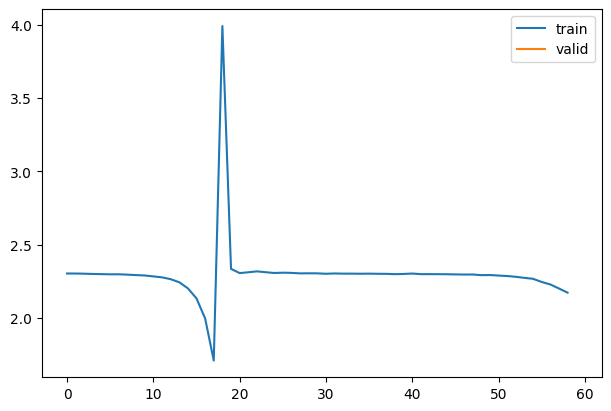

In [64]:
# =====================================================
# USING ACTIVATIONSTATS
# =====================================================

# Create the callback
astats = ActivationStats(mod_filter=lambda m: isinstance(m, nn.Conv2d))

# Train
set_seed(1)
model = nn.Sequential(*cnn_layers())
fit(model, xtra_cbs=[astats])

## 🎮 Interactive: building the `color_dim` heatmap step by step

`color_dim()` is the most informative — and most confusing — plot here. Each **column** is one training batch; each **row** is an activation-magnitude bin (0 at the bottom); **brightness** is how many activations land there. The widget below rebuilds the image in four stages: a single batch's histogram → stacking every batch → transposing into an image → `log1p` + color. Switch the **regime** to compare healthy training against dead ReLUs and exploding activations, and press **Play training** to sweep through the batches.

After you've played with it, run the next cell to see the *real* `color_dim()` on the model you just trained.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/color_dim_explorer.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. Building the color_dim heatmap step by step.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/color_dim_explorer.html", height="640px")

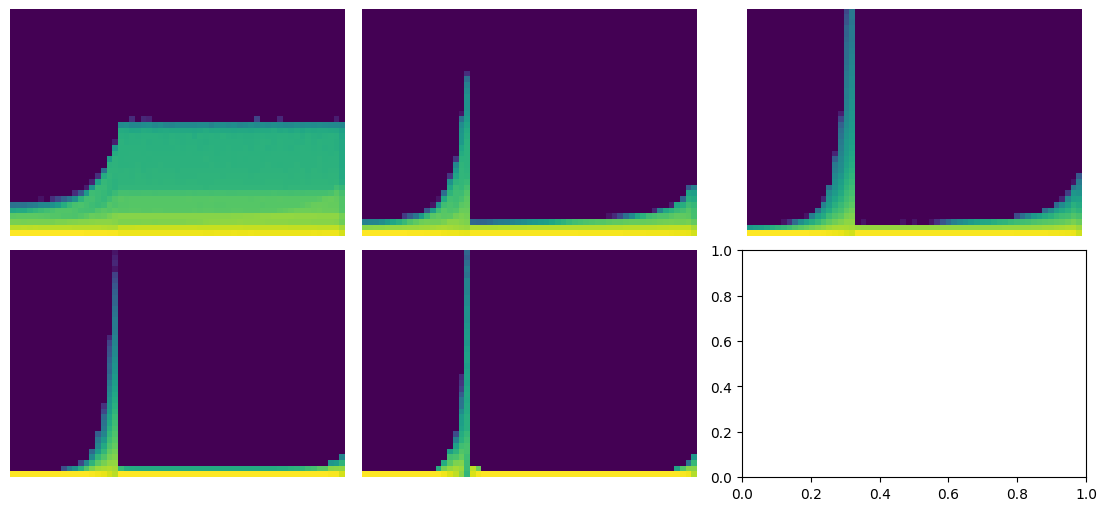

In [66]:
# Visualize activation histograms
astats.color_dim()

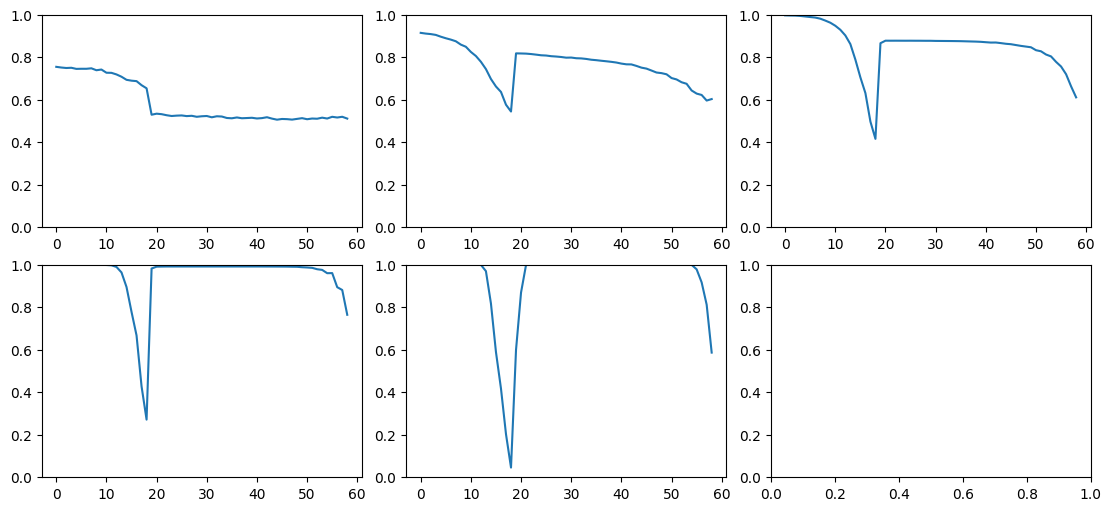

In [67]:
# Check for dead ReLUs
astats.dead_chart()

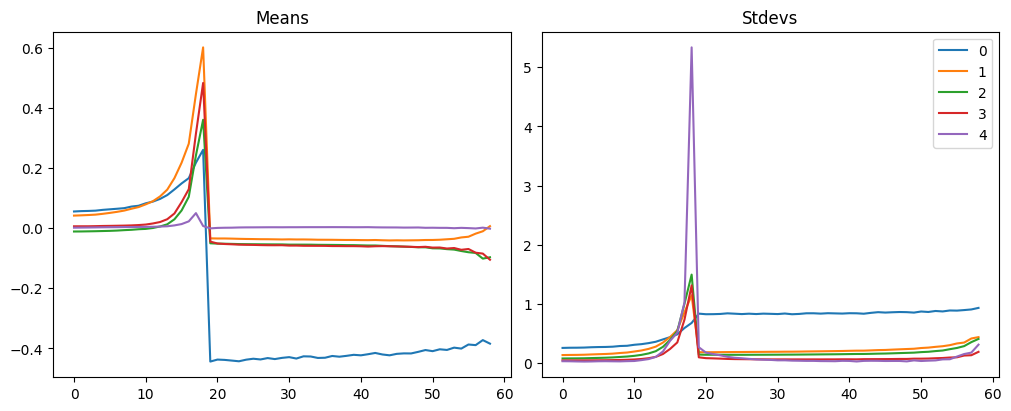

In [68]:
# Plot mean and std
astats.plot_stats()

## 🎮 Interactive: the hook class ladder

We built four classes, each wrapping the one below it and adding **one** convenience: `Hook` → `Hooks` → `HooksCallback` → `ActivationStats`. Click any rung to see what it adds and the exact code, and trace how we went from manually placing a single hook to one-line network monitoring.

In [ ]:
# ============================================================================
# 🎮 INTERACTIVE -- run this cell. Loads interactive_viz/hook_class_hierarchy.html (hosted on
# GitHub Pages) in a full-width iframe that auto-fits its height. The hook class ladder: Hook -> Hooks -> HooksCallback -> ActivationStats.
# Requires the show_viz() setup cell above.
# ============================================================================
show_viz("interactive_viz/hook_class_hierarchy.html", height="430px")

---

# Summary

---

## Key Concepts Learned

### Why Monitor Activations?
- Detect vanishing/exploding activations
- Find dead ReLU neurons
- Debug training problems
- Guide initialization choices

### PyTorch Hooks
- `module.register_forward_hook(fn)` - Called after forward pass
- Hook function receives: `module, input, output`
- Must be removed to prevent memory leaks!

### Our Hook Classes

| Class | Purpose |
|-------|--------|
| **Hook** | Manages a single hook with auto-cleanup |
| **Hooks** | List of hooks with context manager support |
| **HooksCallback** | Integrates hooks with Learner callbacks |
| **ActivationStats** | Easy-to-use activation monitoring |

### Activation Statistics

| Metric | What it Shows |
|--------|---------------|
| **Mean** | Center of activation distribution |
| **Std** | Spread of activations |
| **Histogram** | Full distribution shape |
| **Near-zero fraction** | Dead neuron detection |

### Healthy Activations Should Have:
- Stable mean and std across layers
- Gradual changes during training
- Low fraction of near-zero values
- Histogram spread across reasonable range

---

## What's Next?

In the next notebook, we'll learn about **initialization** - how to start with healthy activations from the beginning!

---